<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Notebook 06 — Typologies du marché immobilier</h3>
  <div style="color: #4b5563; font-size: 14px;">Construction de typologies de marché à l’échelle IRIS et production de variables territoriales réutilisables pour les futures analyses et modèles immobiliers. Objectif du notebook Ce notebook transforme la base résidentielle enrichie en référentiel de marché territorial à l’échelle IRIS. Il agrège les indicateurs de prix, volumes, liquidité et contexte territorial afin de construire des typologies de marché et des variables réutilisables dans les notebooks aval. Position dans le pipeline Le notebook intervient après l’enrichissement territorial. Il ne modifie plus la donnée source : il structure le signal de marché et prépare des variables explicatives destinées aux analyses spatiales, aux comparables immobiliers et aux futurs modèles prédictifs.</div>
</div>

In [ ]:
 
# IMPORTS, CHEMINS ET CONFIGURATION GENERALE

from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Racine projet.
#
# Le notebook est conçu pour être exécuté :
# - depuis le dossier racine du projet ;
# - ou depuis le dossier notebooks.
#
# Aucun chemin personnel n'est conservé afin de rendre
# le notebook portable et publiable sur GitHub.

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name.lower() == "notebooks"
    else CURRENT_DIR
)


# Répertoires de travail.

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"

REPORTS_DIR = PROJECT_ROOT / "reports" / "06_typologies_marche_immobilier"
FIG_DIR = REPORTS_DIR / "figures"
TABLE_DIR = REPORTS_DIR / "tables"
MAP_DIR = REPORTS_DIR / "maps"

for directory in [
    DATA_PROCESSED,
    REPORTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    MAP_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# Entrée canonique produite par le notebook 05.

INPUT_PATH = (
    DATA_PROCESSED
    / "df_biens_residentiels_territoire.parquet"
)


# Sorties canoniques de ce notebook.

TYPOLOGIES_IRIS_OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_iris_typologies_marche.parquet"
)

IRIS_FEATURE_STORE_OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_iris_feature_store_marche.parquet"
)

IRIS_FEATURE_STORE_STRICT_OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_iris_feature_store_marche_strict_safe.parquet"
)

MODEL_FULL_OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_biens_residentiels_typologie_marche.parquet"
)

MODEL_STRICT_SAFE_OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_biens_residentiels_typologie_marche_strict_safe.parquet"
)


# Paramètres globaux du notebook.

RUN_DATE = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

RANDOM_STATE = 42

CONFIG = {
    "prix_m2_quantile_low": 0.01,
    "prix_m2_quantile_high": 0.99,
    "min_transactions_marche_fiable": 20,
    "cluster_k_min": 3,
    "cluster_k_max": 8,
    "departements_geojson_local": str(DATA_EXTERNAL / "departements.geojson"),
    "departements_geojson_url": (
        "https://raw.githubusercontent.com/gregoiredavid/"
        "france-geojson/master/departements-version-simplifiee.geojson"
    ),
    "random_state": RANDOM_STATE,
}


# Contrôle de présence du fichier d'entrée.

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Fichier d'entrée introuvable : "
        f"{INPUT_PATH}\n"
        "Ce fichier doit être produit par le notebook 05."
    )


print("Projet :", PROJECT_ROOT)
print("Entrée :", INPUT_PATH)
print("Sortie principale :", MODEL_FULL_OUTPUT_PATH)
print("Rapports :", REPORTS_DIR)
print("Date d'exécution :", RUN_DATE)

Projet : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Entrée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_territoire.parquet
Sortie principale : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_typologie_marche.parquet
Rapports : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier
Date d'exécution : 2026-05-24 19:08:16


In [ ]:
 
# FONCTIONS UTILITAIRES
 

def save_fig(filename: str) -> Path:
    """Sauvegarde la figure matplotlib courante dans le dossier des figures.

    Parameters
    ----------
    filename : str
        Nom du fichier image à produire.

    Returns
    -------
    Path
        Chemin complet de la figure sauvegardée.
    """
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


def export_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    """Exporte un DataFrame au format CSV UTF-8 compatible Excel."""
    path = TABLE_DIR / filename
    df.to_csv(path, index=index, encoding="utf-8-sig")
    return path


def validate_required_columns(df: pd.DataFrame, required_columns: list[str], context: str) -> None:
    """Vérifie la présence des colonnes obligatoires.

    Dans la philosophie du pipeline, les notebooks aval ne doivent plus deviner
    les noms de colonnes. Le schéma doit être standardisé en amont.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"[{context}] Colonnes obligatoires absentes : {missing}")


def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Retourne la première colonne existante parmi une liste de candidats.

    Cette fonction n'est utilisée que pour des variables enrichies non strictement
    obligatoires. Les clés structurantes restent, elles, validées strictement.
    """
    for col in candidates:
        if col in df.columns:
            return col
    return None


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Calcule un ratio robuste en évitant les divisions par zéro."""
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def add_quantile_bucket(series: pd.Series, labels: list[str]) -> pd.Series:
    """Découpe une série en quantiles avec fallback si les seuils ne sont pas uniques."""
    try:
        return pd.qcut(series, q=len(labels), labels=labels, duplicates="drop")
    except ValueError:
        return pd.Series(pd.NA, index=series.index, dtype="string")


In [ ]:
 
#  FONCTIONS FEATURES + CARTOGRAPHIE
 

def minmax_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    """Transforme une variable numérique en score [0, 1].

    La fonction est robuste aux colonnes constantes ou entièrement manquantes.
    Elle est utilisée pour construire des scores métiers lisibles.
    """
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() == 0 or s.nunique(dropna=True) <= 1:
        return pd.Series(0.5, index=series.index, dtype="float64")
    scaled = (s - s.min()) / (s.max() - s.min())
    return scaled if higher_is_better else 1 - scaled


def weighted_score(df: pd.DataFrame, weights: dict[str, float], directions: dict[str, bool] | None = None) -> pd.Series:
    """Construit un score composite pondéré à partir de colonnes numériques.

    Parameters
    ----------
    df : DataFrame
        Données contenant les colonnes sources.
    weights : dict
        Pondérations par colonne.
    directions : dict
        True si une valeur élevée augmente le score, False sinon.
    """
    directions = directions or {}
    available = [col for col in weights if col in df.columns]
    if not available:
        return pd.Series(np.nan, index=df.index, dtype="float64")

    total_weight = sum(weights[col] for col in available)
    score = pd.Series(0.0, index=df.index, dtype="float64")
    for col in available:
        direction = directions.get(col, True)
        score += weights[col] * minmax_score(df[col], higher_is_better=direction)
    return score / total_weight


def export_feature_dictionary(rows: list[dict], filename: str) -> pd.DataFrame:
    """Exporte le dictionnaire des features produites par le notebook."""
    feature_dict = pd.DataFrame(rows)
    export_table(feature_dict, filename)
    return feature_dict


def aggregate_department_features(iris_df: pd.DataFrame) -> pd.DataFrame:
    """Agrège les features IRIS au niveau département pour la cartographie.

    L'objectif n'est pas de remplacer l'IRIS, mais de produire une lecture synthétique
    et lisible à l'échelle nationale, y compris DOM.
    """
    required = ["code_departement"]
    validate_required_columns(iris_df, required, context="agrégation départementale")

    agg_spec = {
        "nb_iris": ("code_iris", "nunique"),
        "prix_m2_median_dep": ("prix_m2_median", "median"),
        "transactions_count_dep": ("transactions_count", "sum"),
        "score_tension_marche_dep": ("score_tension_marche", "median"),
        "score_premium_marche_dep": ("score_premium_marche", "median"),
        "score_liquidite_marche_dep": ("score_liquidite_marche", "median"),
    }

    dep = iris_df.groupby("code_departement", dropna=False).agg(**agg_spec).reset_index()

    # Typologie et cluster dominants : mode statistique par département.
    if "typologie_metier" in iris_df.columns:
        dominant_typo = (
            iris_df.dropna(subset=["typologie_metier"])
            .groupby("code_departement")["typologie_metier"]
            .agg(lambda s: s.value_counts().index[0] if len(s) else pd.NA)
            .rename("typologie_metier_dominante")
            .reset_index()
        )
        dep = dep.merge(dominant_typo, on="code_departement", how="left", validate="1:1")

    if "cluster_kmeans" in iris_df.columns:
        dominant_cluster = (
            iris_df.dropna(subset=["cluster_kmeans"])
            .groupby("code_departement")["cluster_kmeans"]
            .agg(lambda s: s.value_counts().index[0] if len(s) else pd.NA)
            .rename("cluster_kmeans_dominant")
            .reset_index()
        )
        dep = dep.merge(dominant_cluster, on="code_departement", how="left", validate="1:1")

    dep["code_departement"] = dep["code_departement"].astype("string").str.zfill(2)
    return dep


def load_departements_geometries(config: dict):
    """Charge le fond de carte départemental.

    Dépendance optionnelle : geopandas.
    La fonction privilégie un fichier local, puis une URL configurable.
    """
    try:
        import geopandas as gpd
    except ImportError as exc:
        raise ImportError(
            "La cartographie nécessite geopandas. Installez-le avec : conda install geopandas "
            "ou pip install geopandas. Les exports tabulaires restent utilisables sans cette dépendance."
        ) from exc

    local_geojson = Path(config["departements_geojson_local"])
    geo_source = local_geojson if local_geojson.exists() else config["departements_geojson_url"]
    gdf = gpd.read_file(geo_source)

    # Harmonisation volontairement limitée aux colonnes du fond de carte.
    # Les données métier restent déjà standardisées par le pipeline.
    rename_candidates = {
        "code": "code_departement",
        "CODE_DEPT": "code_departement",
        "DEP": "code_departement",
        "dep": "code_departement",
        "nom": "nom_departement",
        "NOM_DEPT": "nom_departement",
    }
    gdf = gdf.rename(columns={k: v for k, v in rename_candidates.items() if k in gdf.columns})

    validate_required_columns(gdf, ["code_departement", "geometry"], context="fond de carte départements")
    gdf["code_departement"] = gdf["code_departement"].astype("string").str.zfill(2)
    if "nom_departement" not in gdf.columns:
        gdf["nom_departement"] = gdf["code_departement"]

    return gdf[["code_departement", "nom_departement", "geometry"]].copy()


def prepare_department_map_layer(dep_features: pd.DataFrame, config: dict):
    """Joint les features départementales au fond de carte complet.

    Le fond de carte est la table de gauche : tous les départements restent donc visibles.
    C'est le point clé pour éviter une carte qui ne montre que les départements présents
    dans les données ou un territoire incomplet.
    """
    dep_geo = load_departements_geometries(config)
    map_gdf = dep_geo.merge(dep_features, on="code_departement", how="left", validate="1:1")
    map_gdf["donnees_disponibles"] = map_gdf["nb_iris"].notna()
    return map_gdf


def plot_department_feature(map_gdf, column: str, title: str, filename: str, categorical: bool = False):
    """Trace une carte départementale complète avec les départements sans données visibles.

    Le fond blanc/gris clair correspond aux départements présents dans le fond de carte
    mais absents des données DVF/IRIS agrégées.
    """
    import geopandas as gpd

    fig, ax = plt.subplots(1, 1, figsize=(11, 10))

    # 1. Masque complet : tous les départements du fond sont dessinés.
    map_gdf.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.4)

    # 2. Données disponibles : on surimpose la variable d'intérêt.
    has_data = map_gdf[map_gdf[column].notna()].copy()
    if len(has_data) > 0:
        has_data.plot(
            column=column,
            ax=ax,
            legend=True,
            categorical=categorical,
            edgecolor="white",
            linewidth=0.4,
            missing_kwds={"color": "lightgrey", "label": "Non couvert"},
        )

    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

    path = MAP_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


In [ ]:
 
# CHARGEMENT DE L'ENTREE CANONIQUE
 

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Fichier d'entrée introuvable.\n"
        f"Chemin attendu : {INPUT_PATH}\n"
        "Ce fichier doit être produit par le notebook 05_enrichissement_territorial."
    )

source_file = INPUT_PATH
df_raw = pd.read_parquet(INPUT_PATH).copy()

print("Fichier chargé :", source_file.name)
print("Chemin complet :", source_file)
print("Lignes :", f"{len(df_raw):,}")
print("Colonnes :", df_raw.shape[1])
display(df_raw.head(3))


Fichier chargé : df_biens_residentiels_territoire.parquet
Chemin complet : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_territoire.parquet
Lignes : 3,885,803
Colonnes : 131


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,nb_lignes,nb_locaux,nb_appartements,nb_maisons,nb_dependances,surface_bati_totale,surface_terrain_totale,nb_pieces_total,nombre_lots_total,surface_carrez_totale,has_bati,has_terrain,has_imm_special,nb_seg_terrain_a_batir,nb_seg_agricole,nb_seg_agrement,nb_seg_bois_landes,nb_seg_sols,nb_seg_autre,nb_logements,has_logement,has_dependance,mutation_simple_logement,mutation_multiple_logements,ratio_bati_terrain_mutation,type_marche_mutation,type_mutation_economique,avec_dependances,categorie_logement,sous_categorie_logement,type_bien,surface_reference,source_surface_reference,surface_terrain_reference,prix_m2,prix_par_piece,ratio_bati_terrain,flag_valeur_valide,flag_surface_reference_valide,flag_prix_m2_valide,flag_qualite_globale,flag_residentiel,flag_surface_non_positive,flag_valeur_non_positive,flag_prix_m2_non_positif,flag_outlier_valeur_fonciere,flag_outlier_surface_reference,flag_outlier_prix_m2,flag_outlier,prix_m2_recalcule,flag_ecart_prix_m2_10pct,annee_mutation,log_prix_m2,prix_m2_winsor_01_99,log_valeur_fonciere,log_surface_reference,surface_reference_winsor,classe_surface,pieces_info_disponible,surface_par_piece,type_bien_residentiel,is_appartement,is_maison,segment_residentiel_surface,surface_terrain,surface_dependances,terrain_info_disponible,dependance_info_disponible,dependance_surface_info_disponible,ratio_terrain_bati,ratio_dependances_surface,intensite_batie,mois_mutation,trimestre_mutation,annee_mois_mutation,mois_depuis_debut,id_tx_tmp,geometry,code_iris,nom_iris,type_iris,code_commune_tx,code_departement_tx,iris_match_status,nom_iris_territorial,type_iris_territorial,surface_iris_km2,revenu_median,revenu_q1,revenu_q3,indice_inegalite_revenus,taux_pauvrete_60,part_chomage_revenu_disponible,revenu_median_manquant_avant_imputation,revenu_q1_manquant_avant_imputation,revenu_q3_manquant_avant_imputation,indice_inegalite_revenus_manquant_avant_imputation,taux_pauvrete_60_manquant_avant_imputation,part_chomage_revenu_disponible_manquant_avant_imputation,population_2021,taille_menage_moyenne,population_hors_menages,part_population_15_29,part_population_65_plus,nb_logements_2022,part_residences_principales,part_residences_secondaires,part_logements_vacants,part_maisons,part_appartements,nb_equipements_bpe,nb_dpe,score_dpe_moyen,part_dpe_ab,part_dpe_fg,dpe_available,densite_population_km2,densite_logements_km2,iris_code_missing_flag,territorial_match_flag,territorial_unmatched_flag
0,2021-1,2021-01-05,1,Vente,"185,000.000",01312,PRESSIAT,01,5.386,46.327,2,2,0,1,1,97.000,"4,820.000",5.000,0,NaN,True,1.000,False,0,0,0,0,2,0,1,True,1.000,True,False,0.020,marche_secondaire_residentiel,maison,True,Maison,Maison moyenne (80-120 m²),Maison,97.000,bati,"4,820.000","1,907.216","37,000.000",0.020,True,True,True,True,True,False,False,False,False,False,False,False,"1,907.216",False,2021,7.553,"1,907.216",12.128,4.575,97.000,80-100,1,19.400,maison,0,1,maison_standard,"4,820.000",NaN,1,1,0,49.691,NaN,0.020,1,1,2021-01,0,0,"b""\x01\x01\x00\x00\x00\xd5\x06'\xa2_\x8b\x15@\...",013120000,PRESSIAT,Z,01426,1,within,PRESSIAT,Z,6.018,"22,320.000","16,275.000","29,630.000",0.570,18.500,3.150,True,True,True,True,True,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,0.000,<NA>,<NA>,0,1,0
1,2021-10,2021-01-08,1,Vente,"185,000.000",01289,PERONNAS,01,5.210,46.188,1,1,0,1,0,100.000,703.000,4.000,0,NaN,True,1.000,False,0,0,0,0,1,0,1,True,0.000,True,False,0.142,marche_secondaire_residentiel,maison,False,Maison,Maison moyenne (80-120 m²),Maison,100.000,bati,703.000,"1,850.000","46,250.000",0.142,True,True,True,True,True,False,False,False,False,False,False,False,"1,850.000",False,2021,7.523,"1,850.000",12.128,4.605,100.000,80-100,1,25.000,maison,0,1,maison_standard,703.000,NaN,1,1,0,7.030,NaN,0.142,1,1,2021-01,0,1,b'\x01\x01\x00\x00\x00\xdc\xd4@\xf39\xd7\x14@\...,012890102,PERIPHERIE,H

In [ ]:
 
# VALIDATION DU SCHEMA MINIMAL
 

REQUIRED_COLUMNS = [
    "code_iris",
    "code_commune",
    "code_departement",
    "date_mutation",
    "prix_m2",
    "valeur_fonciere",
]

validate_required_columns(df_raw, REQUIRED_COLUMNS, context="schéma d'entrée typologies marché")

# Copie de travail pour préserver l'objet chargé.
df = df_raw.copy()

# Typage explicite des clés et dates.
for col in ["code_iris", "code_commune", "code_departement"]:
    df[col] = df[col].astype("string").str.strip()

df["date_mutation"] = pd.to_datetime(df["date_mutation"], errors="coerce")
df["prix_m2"] = pd.to_numeric(df["prix_m2"], errors="coerce")
df["valeur_fonciere"] = pd.to_numeric(df["valeur_fonciere"], errors="coerce")

schema_report = pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.astype(str).values,
    "taux_na": df.isna().mean().values,
    "nb_na": df.isna().sum().values,
}).sort_values("taux_na", ascending=False)

export_table(schema_report, "01_schema_report.csv")
display(schema_report.head(30))


,colonne,type,taux_na,nb_na
80,ratio_dependances_surface,float64,1.000,3885803
75,surface_dependances,float64,1.000,3885803
19,surface_carrez_totale,float64,0.661,2569505
43,surface_terrain_reference,float64,0.503,1955544
34,ratio_bati_terrain_mutation,float64,0.493,1914222
46,ratio_bati_terrain,float64,0.493,1914222
16,surface_terrain_totale,float64,0.493,1914221
74,surface_terrain,float64,0.493,1914221
81,intensite_batie,float64,0.493,1914221
21,has_terrain,float64,0.493,1914221


In [ ]:
 
# CONSTRUCTION DU PERIMETRE MARCHE
 

base = df.dropna(subset=["code_iris", "date_mutation", "prix_m2"]).copy()
base = base[base["prix_m2"] > 0].copy()

q_low = base["prix_m2"].quantile(CONFIG["prix_m2_quantile_low"])
q_high = base["prix_m2"].quantile(CONFIG["prix_m2_quantile_high"])

base["flag_prix_extreme"] = (
    (base["prix_m2"] < q_low) |
    (base["prix_m2"] > q_high)
).astype("int8")

base_market = base[base["flag_prix_extreme"] == 0].copy()

base_market["annee"] = base_market["date_mutation"].dt.year
base_market["mois"] = base_market["date_mutation"].dt.month
base_market["annee_mois"] = base_market["date_mutation"].dt.to_period("M").astype(str)

filter_report = pd.DataFrame([
    {"etape": "base_initiale", "lignes": len(df)},
    {"etape": "prix_date_iris_non_manquants", "lignes": len(base)},
    {"etape": "base_market_hors_extremes", "lignes": len(base_market)},
])
filter_report["perte_vs_initial_pct"] = 1 - filter_report["lignes"] / len(df)

export_table(filter_report, "02_filter_report.csv")

print("Borne basse prix/m² :", round(q_low, 2))
print("Borne haute prix/m² :", round(q_high, 2))
display(filter_report)


Borne basse prix/m² : 410.0
Borne haute prix/m² : 11618.06


,etape,lignes,perte_vs_initial_pct
0,base_initiale,3885803,0.000
1,prix_date_iris_non_manquants,3881817,0.001
2,base_market_hors_extremes,3804204,0.021


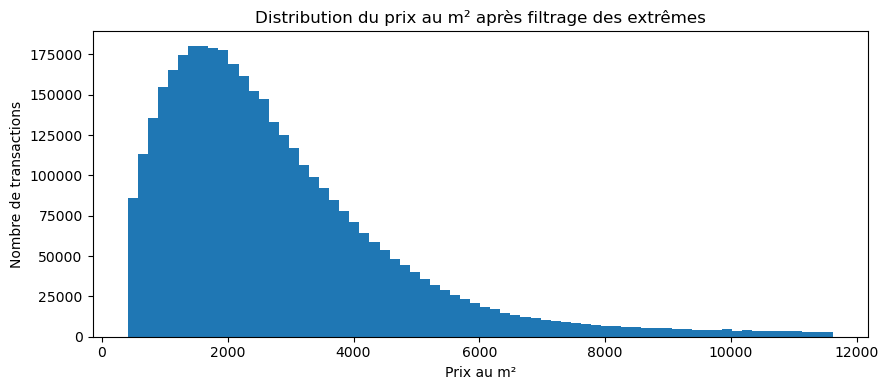

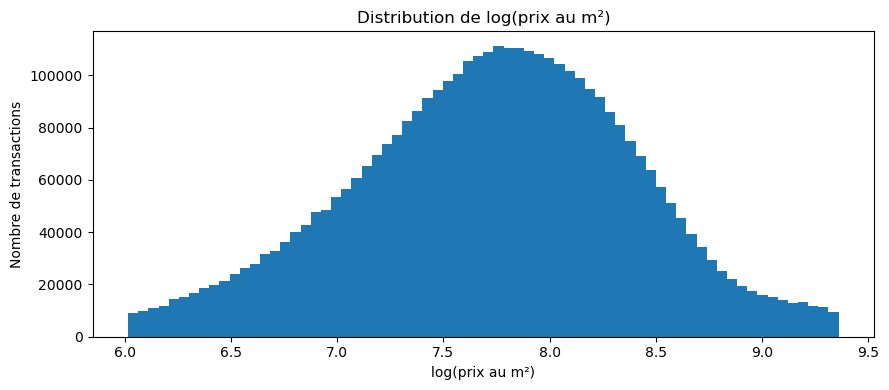

,prix_m2
count,"3,804,204.000"
mean,"2,812.473"
std,"1,887.132"
min,410.000
5%,717.826
10%,938.272
25%,"1,479.167"
50%,"2,355.106"
75%,"3,617.021"
90%,"5,187.500"


In [ ]:
 
# VISUALISATION DES DISTRIBUTIONS
 

plt.figure(figsize=(9, 4))
plt.hist(base_market["prix_m2"], bins=70)
plt.title("Distribution du prix au m² après filtrage des extrêmes")
plt.xlabel("Prix au m²")
plt.ylabel("Nombre de transactions")
save_fig("01_distribution_prix_m2_filtre.png")

plt.figure(figsize=(9, 4))
plt.hist(np.log(base_market["prix_m2"]), bins=70)
plt.title("Distribution de log(prix au m²)")
plt.xlabel("log(prix au m²)")
plt.ylabel("Nombre de transactions")
save_fig("02_distribution_log_prix_m2.png")

prix_summary = base_market["prix_m2"].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).to_frame("prix_m2")
export_table(prix_summary.reset_index().rename(columns={"index": "statistique"}), "03_prix_m2_summary.csv")
display(prix_summary)


In [ ]:
 
# AGREGATION DES INDICATEURS MARCHE PAR IRIS
 

# Variables optionnelles disponibles selon les étapes amont.
surface_col = first_existing_column(df, ["surface_reference", "surface_reelle_bati", "surface_reference_model"])
pieces_col = first_existing_column(df, ["nombre_pieces_principales", "nb_pieces", "pieces"])
type_local_col = first_existing_column(df, ["type_local", "type_bien"])

agg_dict = {
    "prix_m2_median": ("prix_m2", "median"),
    "prix_m2_mean": ("prix_m2", "mean"),
    "prix_m2_q25": ("prix_m2", lambda s: s.quantile(0.25)),
    "prix_m2_q75": ("prix_m2", lambda s: s.quantile(0.75)),
    "prix_m2_std": ("prix_m2", "std"),
    "transactions_count": ("prix_m2", "count"),
    "valeur_fonciere_median": ("valeur_fonciere", "median"),
    "date_min": ("date_mutation", "min"),
    "date_max": ("date_mutation", "max"),
    "nb_mois_observes": ("annee_mois", "nunique"),
}

if surface_col:
    agg_dict["surface_mediane"] = (surface_col, "median")
if pieces_col:
    agg_dict["pieces_medianes"] = (pieces_col, "median")

market_iris = (
    base_market
    .groupby("code_iris")
    .agg(**agg_dict)
    .reset_index()
)

# Indicateurs dérivés robustes.
market_iris["dispersion_prix_iqr"] = market_iris["prix_m2_q75"] - market_iris["prix_m2_q25"]
market_iris["dispersion_prix_relative"] = safe_ratio(market_iris["dispersion_prix_iqr"], market_iris["prix_m2_median"])
market_iris["transactions_par_mois"] = safe_ratio(market_iris["transactions_count"], market_iris["nb_mois_observes"])
market_iris["signal_marche_fiable"] = (market_iris["transactions_count"] >= CONFIG["min_transactions_marche_fiable"]).astype("int8")

# Parts appartement/maison si type_local est disponible.
if type_local_col:
    tmp_types = base_market[["code_iris", type_local_col]].copy()
    tmp_types[type_local_col] = tmp_types[type_local_col].astype("string").str.lower()
    type_stats = (
        tmp_types.assign(
            is_appartement=tmp_types[type_local_col].str.contains("appartement", na=False).astype(int),
            is_maison=tmp_types[type_local_col].str.contains("maison", na=False).astype(int),
        )
        .groupby("code_iris")
        .agg(
            part_appartements=("is_appartement", "mean"),
            part_maisons=("is_maison", "mean"),
        )
        .reset_index()
    )
    market_iris = market_iris.merge(type_stats, on="code_iris", how="left", validate="1:1")

print("Nombre d'IRIS agrégés :", f"{len(market_iris):,}")
display(market_iris.head())


Nombre d'IRIS agrégés : 47,734


,code_iris,prix_m2_median,prix_m2_mean,prix_m2_q25,prix_m2_q75,prix_m2_std,transactions_count,valeur_fonciere_median,date_min,date_max,nb_mois_observes,surface_mediane,dispersion_prix_iqr,dispersion_prix_relative,transactions_par_mois,signal_marche_fiable,part_appartements,part_maisons
0,010010000,"2,552.632","2,562.958","2,197.707","2,862.554",625.970,32,"252,500.000",2021-04-19,2025-12-19,22,95.000,664.847,0.260,1.455,1,0.000,1.000
1,010020000,"1,826.072","1,754.514","1,261.929","2,191.558",717.863,14,"221,450.000",2021-02-09,2025-08-29,14,108.000,929.629,0.509,1.000,0,0.000,1.000
2,010040101,"2,309.716","2,199.324","1,766.131","2,695.487",868.144,92,"205,100.000",2021-01-05,2025-12-15,48,90.000,929.356,0.402,1.917,1,0.326,0.674
3,010040102,"1,944.967","1,894.023","1,224.853","2,453.415",813.287,242,"145,000.000",2021-01-05,2025-12-17,59,85.235,"1,228.562",0.632,4.102,1,0.715,0.285
4,010040201,"2,018.101","2,031.865","1,272.721","2,720.343",971.841,284,"169,500.000",2021-01-05,2025-12-30,59,88.000,"1,447.622",0.717,4.814,1,0.532,0.468


In [ ]:
 
# INTEGRATION DES VARIABLES TERRITORIALES HERITEES
 

# Candidats larges issus des enrichissements territoriaux.
territorial_candidates = [
    # FiLoSoFi / revenus
    "revenu_median", "niveau_vie_median", "mediane_niveau_vie", "filosofi_revenu_median",
    "taux_pauvrete", "part_menages_pauvres",

    # Population / densité
    "population", "population_iris", "pop_iris", "densite_population", "densite_pop",

    # Logements / vacance
    "nb_logements", "logements", "logements_iris", "taux_vacance", "part_logements_vacants",
    "part_residences_principales", "part_residences_secondaires",

    # BPE / équipements
    "nb_equipements", "equipements_total", "densite_equipements", "score_equipements",

    # DPE / énergie
    "dpe_conso_median", "dpe_ges_median", "score_dpe", "part_dpe_a_b", "part_dpe_f_g",

    # Surface IRIS
    "surface_iris_km2", "surface_iris_m2", "superficie_iris_km2",
]

territorial_cols = [col for col in territorial_candidates if col in df.columns]

# On conserve aussi éventuellement les libellés géographiques utiles.
label_cols = [col for col in ["nom_iris", "nom_commune", "nom_departement", "nom_region"] if col in df.columns]

iris_context = (
    df[["code_iris", "code_commune", "code_departement"] + label_cols + territorial_cols]
    .drop_duplicates(subset=["code_iris"])
    .copy()
)

# Merge 1:1 car iris_context a été dédoublonné par code_iris.
market_iris = market_iris.merge(iris_context, on="code_iris", how="left", validate="1:1")

# Recréation de densités si possible.
pop_col = first_existing_column(market_iris, ["population", "population_iris", "pop_iris"])
surface_iris_col = first_existing_column(market_iris, ["surface_iris_km2", "superficie_iris_km2"])
logement_col = first_existing_column(market_iris, ["nb_logements", "logements", "logements_iris"])

def ensure_numeric(col):
    if col and col in market_iris.columns:
        market_iris[col] = pd.to_numeric(market_iris[col], errors="coerce")

for col in [pop_col, surface_iris_col, logement_col]:
    ensure_numeric(col)

if pop_col and surface_iris_col and "densite_population_calculee" not in market_iris.columns:
    market_iris["densite_population_calculee"] = safe_ratio(market_iris[pop_col], market_iris[surface_iris_col])

if logement_col and surface_iris_col and "densite_logements_calculee" not in market_iris.columns:
    market_iris["densite_logements_calculee"] = safe_ratio(market_iris[logement_col], market_iris[surface_iris_col])

territorial_report = pd.DataFrame({
    "variable_territoriale_integree": territorial_cols,
    "taux_na_apres_integration": [market_iris[col].isna().mean() for col in territorial_cols],
})

export_table(territorial_report, "04_variables_territoriales_integrees.csv")
display(territorial_report)


,variable_territoriale_integree,taux_na_apres_integration
0,revenu_median,0.000
1,nb_logements,0.000
2,part_logements_vacants,0.039
3,part_residences_principales,0.039
4,part_residences_secondaires,0.039
5,surface_iris_km2,0.000


In [ ]:
# CONSTRUCTION DES TYPOLOGIES METIER
#
# Objectif :
# attribuer à chaque IRIS une typologie de marché lisible
# à partir de trois dimensions simples :
# - le niveau de prix ;
# - le volume de transactions ;
# - la dispersion des prix.
#
# Cette typologie est volontairement explicite.
# Elle permet d'obtenir une première lecture métier
# avant d'utiliser des méthodes non supervisées comme le clustering.


# Segmentation du niveau de prix.
#
# La fonction add_quantile_bucket découpe la distribution
# du prix médian au m² en classes de taille comparable.
#
# Chaque IRIS reçoit donc une étiquette indiquant
# s'il appartient plutôt à un marché peu cher,
# intermédiaire, élevé ou très élevé.

market_iris["bucket_prix"] = add_quantile_bucket(
    market_iris["prix_m2_median"],
    labels=[
        "prix_bas",
        "prix_intermediaire",
        "prix_eleve",
        "prix_tres_eleve",
    ],
).astype("string")


# Segmentation du volume de transactions.
#
# Cette variable permet de distinguer :
# - les marchés peu liquides ;
# - les marchés modérément actifs ;
# - les marchés avec beaucoup de transactions.
#
# Le volume est important car un prix élevé n'a pas la même robustesse
# s'il repose sur quelques ventes seulement ou sur un marché actif.

market_iris["bucket_volume"] = add_quantile_bucket(
    market_iris["transactions_count"],
    labels=[
        "volume_faible",
        "volume_modere",
        "volume_eleve",
        "volume_tres_eleve",
    ],
).astype("string")


# Segmentation de la dispersion des prix.
#
# La dispersion mesure l'hétérogénéité interne d'un IRIS.
#
# Une dispersion faible suggère un marché relativement homogène.
# Une dispersion élevée peut signaler :
# - des biens très différents dans la même zone ;
# - un marché composite ;
# - ou quelques transactions atypiques.

market_iris["bucket_dispersion"] = add_quantile_bucket(
    market_iris["dispersion_prix_relative"],
    labels=[
        "dispersion_faible",
        "dispersion_moderee",
        "dispersion_elevee",
    ],
).astype("string")


# Définition des règles métier.
#
# Les conditions sont évaluées dans l'ordre.
# La première condition vraie détermine la typologie affectée à l'IRIS.
#
# Cela permet de traduire une logique métier simple :
# - signal insuffisant si le volume est trop faible ;
# - marché premium si prix très élevé et volume important ;
# - marché valorisé si prix élevé avec activité suffisante ;
# - marché actif accessible si volume fort mais prix encore modérés ;
# - marché détendu si prix bas et volume limité.

conditions = [

    # Cas 1 :
    # le volume de transactions est inférieur au seuil minimal.
    # La typologie est alors peu fiable.
    (market_iris["signal_marche_fiable"] == 0),

    # Cas 2 :
    # marché très cher et très liquide.
    (
        market_iris["bucket_prix"].eq("prix_tres_eleve")
        & market_iris["bucket_volume"].isin([
            "volume_eleve",
            "volume_tres_eleve",
        ])
    ),

    # Cas 3 :
    # marché cher ou très cher,
    # avec un volume suffisant pour être interprétable.
    (
        market_iris["bucket_prix"].isin([
            "prix_eleve",
            "prix_tres_eleve",
        ])
        & market_iris["bucket_volume"].isin([
            "volume_modere",
            "volume_eleve",
            "volume_tres_eleve",
        ])
    ),

    # Cas 4 :
    # marché actif mais encore accessible en niveau de prix.
    (
        market_iris["bucket_prix"].isin([
            "prix_bas",
            "prix_intermediaire",
        ])
        & market_iris["bucket_volume"].isin([
            "volume_eleve",
            "volume_tres_eleve",
        ])
    ),

    # Cas 5 :
    # marché peu cher et peu ou modérément actif.
    (
        market_iris["bucket_prix"].eq("prix_bas")
        & market_iris["bucket_volume"].isin([
            "volume_faible",
            "volume_modere",
        ])
    ),
]


# Libellés associés aux règles précédentes.
#
# L'ordre doit correspondre exactement à celui de la liste conditions.

choices = [
    "signal_insuffisant",
    "marche_premium_liquide",
    "marche_valorise",
    "marche_actif_accessible",
    "marche_detendu",
]


# Affectation de la typologie métier.
#
# np.select applique les règles dans l'ordre.
# Si aucune condition n'est remplie, l'IRIS est classé
# en marché intermédiaire.

market_iris["typologie_metier"] = np.select(
    conditions,
    choices,
    default="marche_intermediaire",
)


# Création d'un référentiel lisible des règles.
#
# Ce tableau documente la logique de classement.
# Il sert à rendre la typologie transparente,
# vérifiable et compréhensible par un lecteur métier.

TYPOLOGIE_RULES = pd.DataFrame([
    {
        "typologie_metier": "signal_insuffisant",
        "definition": (
            "Volume de transactions inférieur au seuil minimal de fiabilité."
        ),
        "logique": (
            f"transactions_count < "
            f"{CONFIG['min_transactions_marche_fiable']}"
        ),
    },
    {
        "typologie_metier": "marche_premium_liquide",
        "definition": (
            "Prix très élevés et volume élevé ou très élevé."
        ),
        "logique": (
            "bucket_prix = prix_tres_eleve "
            "ET bucket_volume ∈ {volume_eleve, volume_tres_eleve}"
        ),
    },
    {
        "typologie_metier": "marche_valorise",
        "definition": (
            "Marché cher, mais pas nécessairement premium liquide."
        ),
        "logique": (
            "prix élevé ou très élevé avec volume au moins modéré"
        ),
    },
    {
        "typologie_metier": "marche_actif_accessible",
        "definition": (
            "Marché actif avec prix bas ou intermédiaires."
        ),
        "logique": (
            "prix bas/intermédiaire ET volume élevé/très élevé"
        ),
    },
    {
        "typologie_metier": "marche_detendu",
        "definition": (
            "Prix bas et volume faible à modéré."
        ),
        "logique": (
            "prix_bas ET volume_faible/modere"
        ),
    },
    {
        "typologie_metier": "marche_intermediaire",
        "definition": (
            "Cas résiduel sans signal extrême clair."
        ),
        "logique": "défaut",
    },
])


# Export du référentiel de typologie.
#
# Ce fichier permet de conserver une trace externe
# des règles de classement utilisées dans le notebook.

export_table(
    TYPOLOGIE_RULES,
    "06_referentiel_typologies_metier.csv",
)


# Distribution des IRIS par typologie.
#
# Ce tableau permet de vérifier :
# - le poids de chaque catégorie ;
# - l'équilibre de la segmentation ;
# - la présence éventuelle de catégories trop rares.

typologie_counts = (
    market_iris["typologie_metier"]
    .value_counts(dropna=False)
    .rename_axis("typologie_metier")
    .reset_index(name="nb_iris")
)


# Calcul de la part relative de chaque typologie.

typologie_counts["part_iris"] = (
    typologie_counts["nb_iris"]
    / typologie_counts["nb_iris"].sum()
)


# Export de la distribution des typologies.
#
# Cette sortie permet de documenter la structure finale
# de la segmentation métier.

export_table(
    typologie_counts,
    "07_typologie_metier_distribution.csv",
)


# Affichage du référentiel et de la distribution.
#
# Le premier tableau explique les règles.
# Le second montre leur effet sur les IRIS.

display(TYPOLOGIE_RULES)

display(typologie_counts)

,typologie_metier,definition,logique
0,signal_insuffisant,Volume de transactions inférieur au seuil mini...,transactions_count < 20
1,marche_premium_liquide,Prix très élevés et volume élevé ou très élevé.,bucket_prix = prix_tres_eleve ET bucket_volume...
2,marche_valorise,"Marché cher, mais pas nécessairement premium l...",prix élevé ou très élevé avec volume au moins ...
3,marche_actif_accessible,Marché actif avec prix bas ou intermédiaires.,prix bas/intermédiaire ET volume élevé/très élevé
4,marche_detendu,Prix bas et volume faible à modéré.,prix_bas ET volume_faible/modere
5,marche_intermediaire,Cas résiduel sans signal extrême clair.,défaut


,typologie_metier,nb_iris,part_iris
0,signal_insuffisant,18348,0.384
1,marche_premium_liquide,9757,0.204
2,marche_valorise,8589,0.180
3,marche_actif_accessible,7494,0.157
4,marche_intermediaire,1827,0.038
5,marche_detendu,1719,0.036


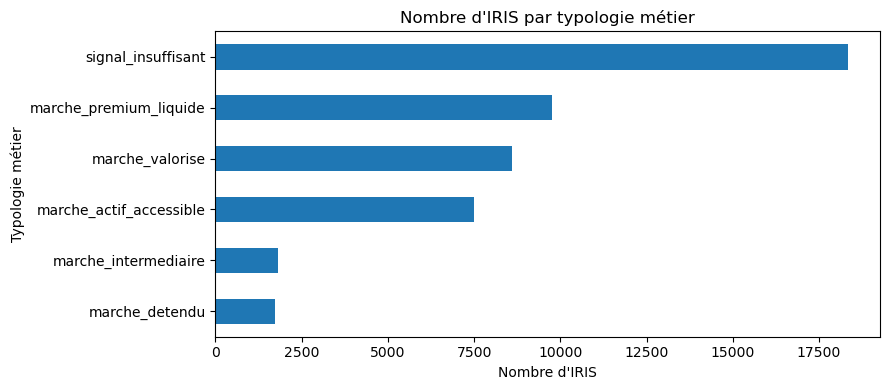

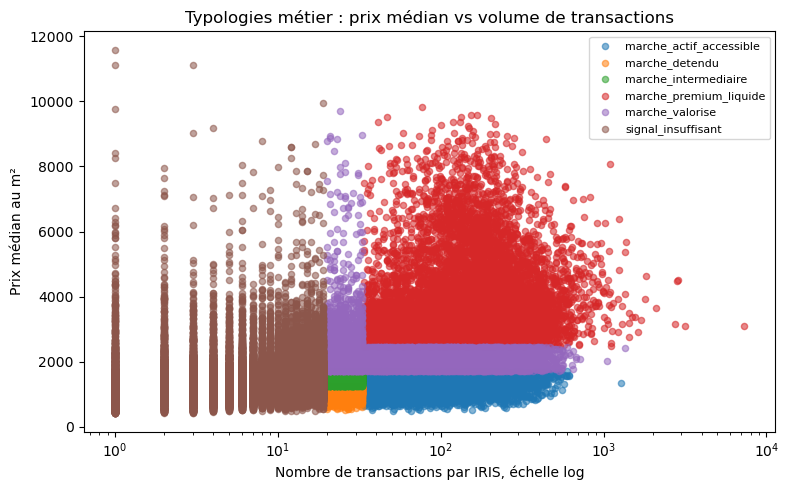

WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/figures/05_typologies_metier_prix_volume.png')

In [ ]:
 
# VISUALISATION DES TYPOLOGIES METIER
 

plt.figure(figsize=(9, 4))
typologie_counts.sort_values("nb_iris").plot(
    x="typologie_metier",
    y="nb_iris",
    kind="barh",
    legend=False,
    ax=plt.gca()
)
plt.title("Nombre d'IRIS par typologie métier")
plt.xlabel("Nombre d'IRIS")
plt.ylabel("Typologie métier")
save_fig("04_distribution_typologies_metier.png")

plt.figure(figsize=(8, 5))
for typologie, sub in market_iris.groupby("typologie_metier"):
    plt.scatter(
        sub["transactions_count"],
        sub["prix_m2_median"],
        alpha=0.55,
        label=typologie,
        s=20,
    )
plt.xscale("log")
plt.title("Typologies métier : prix médian vs volume de transactions")
plt.xlabel("Nombre de transactions par IRIS, échelle log")
plt.ylabel("Prix médian au m²")
plt.legend(fontsize=8, loc="best")
save_fig("05_typologies_metier_prix_volume.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — typologies métier du marché immobilier</h3>
  <div style="color: #4b5563; font-size: 14px;">Les visualisations mettent en évidence une forte hétérogénéité des marchés immobiliers à l’échelle IRIS. La catégorie `signal_insuffisant` reste majoritaire, traduisant un volume de transactions limité sur une partie importante du territoire. Cette situation est cohérente avec la granularité fine du maillage IRIS. Les typologies exploitables représentent néanmoins plusieurs milliers d’IRIS et permettent déjà d’identifier différents profils de marché : marchés premium et liquides ; marchés valorisés mais moins actifs ; marchés accessibles à forte activité ; marchés plus détendus et peu liquides. Le nuage de points confirme la cohérence de la segmentation entre niveau de prix et intensité transactionnelle. Les marchés premium se concentrent sur les niveaux de prix et de volumes les plus élevés, tandis que les IRIS à signal insuffisant restent associés aux faibles volumes. Les résultats montrent également que prix élevés et liquidité ne sont pas systématiquement liés, certains marchés restant très actifs malgré des niveaux de prix plus accessibles. Enfin, les typologies construites conservent une forte interprétabilité métier. La segmentation repose sur des règles explicites liées au prix, à la liquidité et à l’intensité du marché, plutôt que sur un clustering purement algorithmique.</div>
</div>

In [ ]:
 
# SELECTION DES VARIABLES POUR LE CLUSTERING
 

base_cluster_features = [
    "prix_m2_median",
    "transactions_count",
    "dispersion_prix_relative",
    "transactions_par_mois",
    "surface_mediane",
    "pieces_medianes",
    "part_appartements",
    "part_maisons",
]

# Ajout de variables territoriales numériques si présentes.
territorial_numeric_candidates = [
    "revenu_median", "niveau_vie_median", "mediane_niveau_vie", "filosofi_revenu_median",
    "population", "population_iris", "pop_iris",
    "densite_population", "densite_pop", "densite_population_calculee",
    "nb_logements", "logements", "logements_iris", "densite_logements_calculee",
    "taux_vacance", "part_logements_vacants",
    "nb_equipements", "equipements_total", "densite_equipements", "score_equipements",
    "dpe_conso_median", "dpe_ges_median", "score_dpe", "part_dpe_a_b", "part_dpe_f_g",
]

cluster_features = []
for col in base_cluster_features + territorial_numeric_candidates:
    if col in market_iris.columns:
        # On convertit en numérique avec prudence ; les colonnes non numériques deviendront NaN.
        market_iris[col] = pd.to_numeric(market_iris[col], errors="coerce")
        missing_rate = market_iris[col].isna().mean()
        # Seuil de couverture : on garde les variables présentes sur au moins 70 % des IRIS.
        if missing_rate <= 0.30 and market_iris[col].nunique(dropna=True) > 3:
            cluster_features.append(col)

cluster_features = list(dict.fromkeys(cluster_features))

if len(cluster_features) < 3:
    raise ValueError(
        "Moins de 3 variables exploitables pour le clustering. "
        "Vérifier les enrichissements territoriaux et la couverture des colonnes."
    )

cluster_feature_report = pd.DataFrame({
    "feature": cluster_features,
    "taux_na": [market_iris[col].isna().mean() for col in cluster_features],
    "n_unique": [market_iris[col].nunique(dropna=True) for col in cluster_features],
})

export_table(cluster_feature_report, "08_cluster_features_retenues.csv")
display(cluster_feature_report)


,feature,taux_na,n_unique
0,prix_m2_median,0.000,37550
1,transactions_count,0.000,745
2,dispersion_prix_relative,0.000,46802
3,transactions_par_mois,0.000,2860
4,surface_mediane,0.000,5365
5,part_appartements,0.000,9108
6,part_maisons,0.000,9108
7,revenu_median,0.000,2850
8,densite_logements_calculee,0.000,47734
9,part_logements_vacants,0.039,42744


Nombre de clusters retenu automatiquement : 3


,k,inertia,silhouette_score
0,3,"291,545.995",0.410
1,4,"262,773.962",0.184
2,5,"241,819.056",0.184
3,6,"223,858.111",0.191
4,7,"211,180.274",0.182
5,8,"200,370.317",0.184


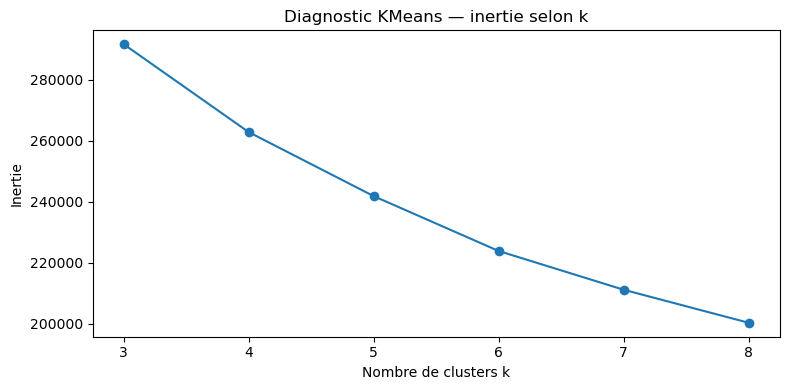

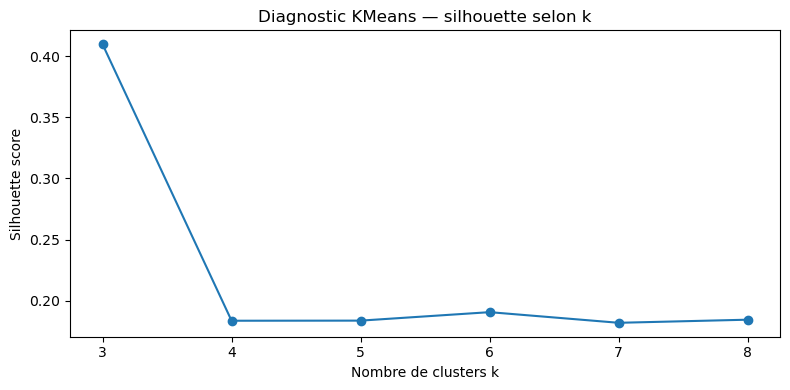

WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/figures/07_kmeans_silhouette.png')

In [ ]:
# STANDARDISATION ET DIAGNOSTIC KMEANS
#
# Objectif :
# préparer les variables IRIS au clustering non supervisé,
# puis tester plusieurs nombres de clusters pour choisir une segmentation cohérente.

# Sous-base utilisée pour le clustering :
# - code_iris sert d'identifiant ;
# - cluster_features contient les variables quantitatives de segmentation.
cluster_df = market_iris[["code_iris"] + cluster_features].copy()

# KMeans ne gère pas les valeurs manquantes.
# On applique donc une imputation simple par médiane, variable par variable.
# Cette imputation est limitée au clustering exploratoire.
for col in cluster_features:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

# Matrice numérique utilisée par l'algorithme.
X = cluster_df[cluster_features].to_numpy()

# Standardisation des variables.
# Elle est indispensable car les variables n'ont pas les mêmes unités :
# euros, volumes, pourcentages, densités, etc.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plage de nombres de clusters à tester.
# Les bornes sont définies dans CONFIG pour garder le notebook paramétrable.
k_values = list(range(CONFIG["cluster_k_min"], CONFIG["cluster_k_max"] + 1))

cluster_diagnostics = []

# Test de plusieurs segmentations KMeans.
# Pour chaque k, on mesure :
# - l'inertie : compacité interne des groupes ;
# - le score de silhouette : qualité de séparation des groupes.
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=CONFIG["random_state"],
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    cluster_diagnostics.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": sil,
    })

# Tableau de synthèse des diagnostics.
cluster_diagnostics = pd.DataFrame(cluster_diagnostics)

# Sélection automatique du nombre de clusters.
# On retient ici le k qui maximise le score de silhouette.
best_k = int(
    cluster_diagnostics
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

# Export du diagnostic pour audit et traçabilité.
export_table(cluster_diagnostics, "09_kmeans_diagnostics.csv")

print("Nombre de clusters retenu automatiquement :", best_k)
display(cluster_diagnostics)

# Graphique d'inertie.
# Il permet d'observer si un effet de coude apparaît lorsque k augmente.
plt.figure(figsize=(8, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["inertia"],
    marker="o"
)
plt.title("Diagnostic KMeans — inertie selon k")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
save_fig("06_kmeans_inertie.png")

# Graphique du score de silhouette.
# Il permet d'identifier le nombre de clusters le mieux séparé.
plt.figure(figsize=(8, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["silhouette_score"],
    marker="o"
)
plt.title("Diagnostic KMeans — silhouette selon k")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette score")
save_fig("07_kmeans_silhouette.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — diagnostic du nombre de clusters KMeans</h3>
  <div style="color: #4b5563; font-size: 14px;">Les graphiques permettent d’évaluer la stabilité des segmentations KMeans selon différents nombres de clusters. L’inertie diminue progressivement lorsque le nombre de clusters augmente, avec un ralentissement visible autour de `k = 4` ou `k = 5`. Ce comportement suggère l’existence d’une structure sous-jacente dans les données. Le score de silhouette apporte une lecture plus discriminante. Le modèle à `k = 3` présente le meilleur niveau de séparation entre groupes, avec un score nettement supérieur aux segmentations plus fines. Ces résultats indiquent que les données semblent naturellement organisées autour de quelques grands profils territoriaux relativement distincts. Lorsque le nombre de clusters augmente, les groupes deviennent plus détaillés mais également moins bien séparés statistiquement. D’un point de vue métier, un faible nombre de clusters favorise l’interprétabilité des segments, tandis qu’un nombre plus élevé permet une lecture territoriale plus fine au prix d’une moindre robustesse statistique. La segmentation non supervisée apparaît ainsi pertinente pour compléter les typologies métier et structurer les futurs enrichissements territoriaux du pipeline immobilier.</div>
</div>

In [ ]:
 
# CLUSTERING FINAL
 

final_kmeans = KMeans(n_clusters=best_k, random_state=CONFIG["random_state"], n_init=50)
market_iris["cluster_kmeans"] = final_kmeans.fit_predict(X_scaled).astype("int16")

# Distance au centroïde : indicateur utile pour repérer les IRIS atypiques dans leur cluster.
centroids = final_kmeans.cluster_centers_
labels = market_iris["cluster_kmeans"].to_numpy()
market_iris["distance_centroid_cluster"] = np.linalg.norm(X_scaled - centroids[labels], axis=1)

cluster_counts = (
    market_iris["cluster_kmeans"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_kmeans")
    .reset_index(name="nb_iris")
)
cluster_counts["part_iris"] = cluster_counts["nb_iris"] / cluster_counts["nb_iris"].sum()

export_table(cluster_counts, "10_cluster_distribution.csv")
display(cluster_counts)


,cluster_kmeans,nb_iris,part_iris
0,0,36006,0.754
1,1,10055,0.211
2,2,1673,0.035


In [ ]:
# PROFILAGE DES CLUSTERS KMEANS
#
# Objectif :
# résumer les caractéristiques de chaque cluster afin de pouvoir
# interpréter les groupes produits par KMeans.
#
# KMeans attribue des numéros de clusters, mais ces numéros
# n'ont pas de signification métier en eux-mêmes.
# Cette étape permet donc de comprendre ce que représente chaque groupe.


# Tableau de synthèse par cluster.
#
# On calcule ici les médianes des principales variables immobilières :
# - nombre d'IRIS dans le cluster ;
# - prix médian au m² ;
# - volume médian de transactions ;
# - dispersion relative des prix ;
# - nombre médian de transactions par mois.
#
# La médiane est privilégiée car elle est plus robuste aux valeurs extrêmes
# que la moyenne.

cluster_profile = (
    market_iris
    .groupby("cluster_kmeans")
    .agg(
        nb_iris=("code_iris", "count"),
        prix_m2_median=("prix_m2_median", "median"),
        transactions_count_median=("transactions_count", "median"),
        dispersion_relative_median=("dispersion_prix_relative", "median"),
        transactions_par_mois_median=("transactions_par_mois", "median"),
    )
    .reset_index()
)


# Ajout dynamique des autres variables utilisées dans le clustering.
#
# Certaines variables présentes dans cluster_features peuvent ne pas
# avoir été incluses explicitement dans l'agrégation ci-dessus.
#
# Cette boucle garantit que le profil des clusters contient bien
# une médiane pour chaque variable utilisée par KMeans.

for col in cluster_features:

    out_col = f"{col}_median"

    if out_col not in cluster_profile.columns:

        add_profile = (
            market_iris
            .groupby("cluster_kmeans")[col]
            .median()
            .rename(out_col)
            .reset_index()
        )

        cluster_profile = cluster_profile.merge(
            add_profile,
            on="cluster_kmeans",
            how="left",
            validate="1:1"
        )


# Export du profil des clusters.
#
# Ce fichier permet de documenter l'interprétation des groupes
# et de conserver une trace de la segmentation produite.

export_table(
    cluster_profile,
    "11_cluster_profile.csv"
)

display(cluster_profile)


# Préparation de la heatmap des profils.
#
# L'objectif est de comparer visuellement les clusters
# sur l'ensemble des variables.
#
# On place les clusters en lignes
# et les variables en colonnes.

profile_for_heatmap = cluster_profile.set_index("cluster_kmeans")


# On retire nb_iris de la heatmap.
#
# Cette variable décrit la taille du cluster,
# mais elle ne caractérise pas directement son profil économique.

num_cols_heatmap = [
    c for c in profile_for_heatmap.columns
    if c != "nb_iris"
]


# Conversion explicite en numérique.
#
# Cette étape sécurise plt.imshow,
# qui attend une matrice numérique.
# Elle évite les erreurs liées aux colonnes de type object.

profile_numeric = (
    profile_for_heatmap[num_cols_heatmap]
    .apply(pd.to_numeric, errors="coerce")
)


# Standardisation des profils.
#
# Chaque variable est centrée-réduite :
# - 0 signifie que le cluster est proche de la moyenne ;
# - une valeur positive signifie que le cluster est au-dessus de la moyenne ;
# - une valeur négative signifie qu'il est en dessous.
#
# Cette transformation rend comparables des variables exprimées
# dans des unités différentes.

profile_scaled = (
    profile_numeric
    - profile_numeric.mean()
) / profile_numeric.std(ddof=0)


# Matrice finale utilisée par la heatmap.
#
# Les éventuelles valeurs manquantes sont remplacées par 0,
# ce qui revient à les positionner au niveau moyen après standardisation.

profile_matrix = (
    profile_scaled
    .fillna(0.0)
    .to_numpy(dtype=float)
)


# Heatmap des profils standardisés.
#
# Cette visualisation permet d'identifier rapidement :
# - les clusters plus chers ;
# - les clusters plus liquides ;
# - les clusters plus dispersés ;
# - les clusters plus urbains ou plus résidentiels selon les variables.
#
# La couleur ne représente pas une valeur brute,
# mais un écart au profil moyen.

plt.figure(
    figsize=(
        max(10, len(num_cols_heatmap) * 0.6),
        5
    )
)

plt.imshow(
    profile_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(num_cols_heatmap)),
    num_cols_heatmap,
    rotation=75,
    ha="right"
)

plt.yticks(
    range(len(profile_scaled.index)),
    profile_scaled.index
)

plt.title("Profil standardisé des clusters KMeans")

plt.colorbar(
    label="Écart standardisé au profil moyen"
)

plt.xlabel("Variables")
plt.ylabel("Cluster")

save_fig("08_heatmap_profils_clusters.png")


,axe,variance_expliquee
0,pca_1,0.416
1,pca_2,0.143


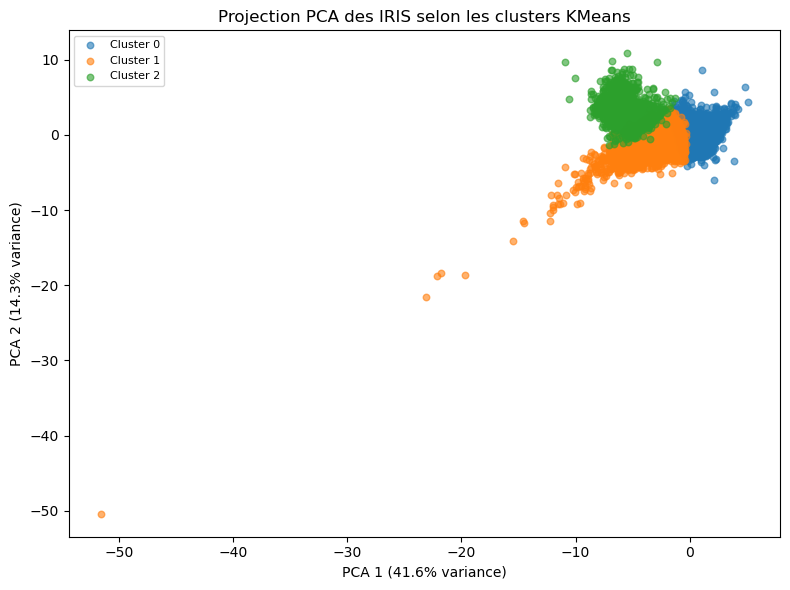

WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/figures/09_pca_clusters_kmeans.png')

In [ ]:
 
# PROJECTION PCA DES CLUSTERS
 

pca = PCA(n_components=2, random_state=CONFIG["random_state"])
coords = pca.fit_transform(X_scaled)

market_iris["pca_1"] = coords[:, 0]
market_iris["pca_2"] = coords[:, 1]

pca_report = pd.DataFrame({
    "axe": ["pca_1", "pca_2"],
    "variance_expliquee": pca.explained_variance_ratio_,
})
export_table(pca_report, "12_pca_variance_expliquee.csv")
display(pca_report)

plt.figure(figsize=(8, 6))
for cluster_id, sub in market_iris.groupby("cluster_kmeans"):
    plt.scatter(sub["pca_1"], sub["pca_2"], alpha=0.6, s=22, label=f"Cluster {cluster_id}")
plt.title("Projection PCA des IRIS selon les clusters KMeans")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(fontsize=8)
save_fig("09_pca_clusters_kmeans.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — projection PCA des clusters KMeans</h3>
  <div style="color: #4b5563; font-size: 14px;">La projection PCA met en évidence une structure territoriale globalement cohérente des clusters KMeans. Le cluster principal regroupe des IRIS plus hétérogènes et concentre plusieurs points atypiques, probablement associés à des marchés peu liquides ou à des profils territoriaux spécifiques. Cette dispersion traduit une forte variabilité des situations immobilières observées. Les clusters les plus compacts correspondent davantage à des marchés homogènes, souvent associés à des territoires plus denses, plus valorisés ou économiquement plus structurés. Le premier axe PCA concentre l’essentiel de la variance et semble principalement refléter les différences de niveau de marché : prix, activité transactionnelle, densité et attractivité territoriale. Le second axe apporte une différenciation plus fine, liée à des caractéristiques secondaires du parc résidentiel ou du contexte socio-économique. Quelques observations restent fortement isolées du nuage principal. Ces points atypiques peuvent correspondre à des marchés très spécifiques ou à des configurations territoriales rares. Leur influence devra être surveillée dans les futures phases de modélisation. Globalement, la projection confirme que le clustering capture une structure réelle du marché immobilier à l’échelle IRIS. Les frontières entre segments restent toutefois progressives, ce qui reflète le caractère continu des dynamiques territoriales.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Croisement typologie métier et clusters</h3>
  <div style="color: #4b5563; font-size: 14px;">Le croisement compare deux lectures : les règles métier explicites et la segmentation statistique. Une convergence renforce la crédibilité des typologies ; une divergence signale des marchés où la structure des données nuance les règles simples.</div>
</div>

cluster_kmeans,0,1,2,All
typologie_metier,,,,
marche_actif_accessible,5656,1835,3,7494
marche_detendu,1662,56,1,1719
marche_intermediaire,1797,30,0,1827
marche_premium_liquide,2824,5404,1529,9757
marche_valorise,6166,2355,68,8589
signal_insuffisant,17901,375,72,18348
All,36006,10055,1673,47734


cluster_kmeans,0,1,2
typologie_metier,,,
marche_actif_accessible,0.755,0.245,0.000
marche_detendu,0.967,0.033,0.001
marche_intermediaire,0.984,0.016,0.000
marche_premium_liquide,0.289,0.554,0.157
marche_valorise,0.718,0.274,0.008
signal_insuffisant,0.976,0.020,0.004


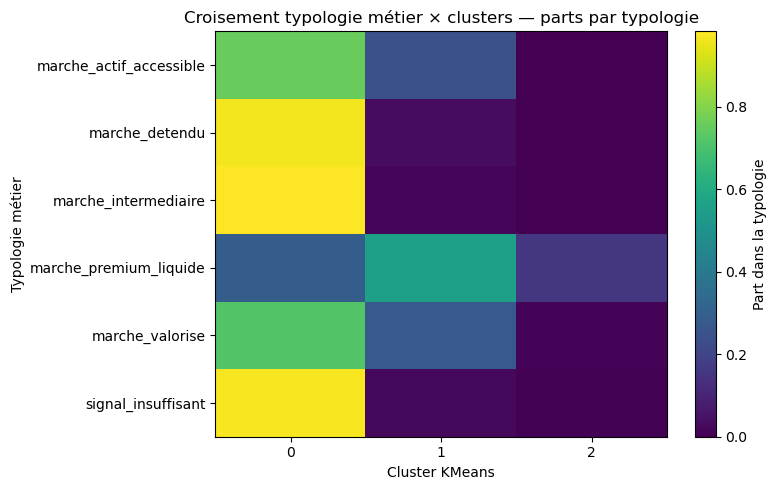

WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/figures/10_heatmap_typologie_vs_cluster.png')

In [19]:

# Croisement entre la typologie métier et les clusters KMeans.
# Ce tableau vérifie si les règles métier et la segmentation statistique convergent.
cross_typology_cluster = pd.crosstab(
    market_iris["typologie_metier"],
    market_iris["cluster_kmeans"],
    margins=True,
)

cross_typology_cluster_pct = pd.crosstab(
    market_iris["typologie_metier"],
    market_iris["cluster_kmeans"],
    normalize="index",
)

export_table(cross_typology_cluster.reset_index(), "13_croisement_typologie_cluster_counts.csv")
export_table(cross_typology_cluster_pct.reset_index(), "14_croisement_typologie_cluster_pct.csv")

display(cross_typology_cluster)
display(cross_typology_cluster_pct)

# Heatmap — conversion en matrice float obligatoire pour plt.imshow.
cross_matrix = cross_typology_cluster_pct.fillna(0.0).to_numpy(dtype=float)

plt.figure(figsize=(8, 5))
plt.imshow(cross_matrix, aspect="auto")
plt.xticks(range(len(cross_typology_cluster_pct.columns)), cross_typology_cluster_pct.columns)
plt.yticks(range(len(cross_typology_cluster_pct.index)), cross_typology_cluster_pct.index)
plt.title("Croisement typologie métier × clusters — parts par typologie")
plt.xlabel("Cluster KMeans")
plt.ylabel("Typologie métier")
plt.colorbar(label="Part dans la typologie")
save_fig("10_heatmap_typologie_vs_cluster.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Cluster 1 : cluster des marchés valorisés</h3>
  <div style="color: #4b5563; font-size: 14px;">Le cluster 1 concentre fortement : les marchés premium liquides ; les marchés valorisés. Par exemple : 404 IRIS premium liquides ; 355 IRIS valorisés. Ce cluster semble capturer : les marchés urbains dynamiques ; les zones attractives ; les territoires chers et liquides. Commentaires — projection PCA des clusters KMeans La projection PCA met en évidence une structure territoriale globalement cohérente des clusters KMeans. Le cluster principal regroupe des IRIS plus hétérogènes et concentre plusieurs points atypiques, probablement associés à des marchés peu liquides ou à des profils territoriaux spécifiques. Cette dispersion traduit une forte variabilité des situations immobilières observées. Les clusters les plus compacts correspondent davantage à des marchés homogènes, souvent associés à des territoires plus denses, plus valorisés ou économiquement plus structurés. Le premier axe PCA concentre l’essentiel de la variance et semble principalement refléter les différences de niveau de marché : prix, activité transactionnelle, densité et attractivité territoriale. Le second axe apporte une différenciation plus fine, liée à des caractéristiques secondaires du parc résidentiel ou du contexte socio-économique. Quelques observations restent fortement isolées du nuage principal. Ces points atypiques peuvent correspondre à des marchés très spécifiques ou à des configurations territoriales rares. Leur influence devra être surveillée dans les futures phases de modélisation. Globalement, la projection confirme que le clustering capture une structure réelle du marché immobilier à l’échelle IRIS. Les frontières entre segments restent toutefois progressives, ce qui reflète le caractère continu des dynamiques territoriales.</div>
</div>

In [ ]:
 
# IDENTIFICATION DES IRIS LES PLUS ATYPIQUES
#
# Objectif :
# détecter les IRIS les plus éloignés du comportement moyen
# de leur cluster KMeans.
#
# Ces IRIS peuvent correspondre :
# - à des marchés immobiliers très spécifiques ;
# - à des territoires rares ;
# - à des zones très hétérogènes ;
# - ou à des anomalies statistiques potentielles.


# Variables que l'on souhaite afficher dans le tableau final.
#
# On conserve :
# - les identifiants géographiques ;
# - la typologie métier ;
# - le cluster KMeans ;
# - la distance au centroïde ;
# - ainsi que les principaux indicateurs de marché.

cols_display = [
    "code_iris",
    "code_commune",
    "code_departement",
    "typologie_metier",
    "cluster_kmeans",
    "distance_centroid_cluster",
    "prix_m2_median",
    "transactions_count",
    "dispersion_prix_relative",
]


# Ajout conditionnel des noms géographiques.
#
# Certains jeux de données peuvent ne pas contenir
# nom_iris ou nom_commune.
#
# Cette boucle permet d'ajouter automatiquement
# ces colonnes si elles existent.

for col in ["nom_iris", "nom_commune"]:

    if col in market_iris.columns and col not in cols_display:

        # Insertion au début pour améliorer la lisibilité du tableau.
        cols_display.insert(1, col)


# Construction du tableau des IRIS atypiques.
#
# distance_centroid_cluster mesure la distance
# entre un IRIS et le centre statistique de son cluster.
#
# Plus cette distance est élevée :
# - plus l'IRIS est atypique ;
# - plus son profil diffère des autres IRIS du groupe.

iris_atypiques = (
    market_iris[cols_display]

    # Tri décroissant :
    # les IRIS les plus atypiques apparaissent en premier.
    .sort_values(
        "distance_centroid_cluster",
        ascending=False
    )

    # On conserve uniquement les 50 cas les plus extrêmes.
    .head(50)
)


# Export du tableau.
#
# Ce fichier peut être utilisé :
# - pour audit ;
# - pour contrôle qualité ;
# - pour analyse métier ;
# - ou pour étudier des micro-marchés particuliers.

export_table(
    iris_atypiques,
    "15_iris_atypiques_top50.csv"
)


# Affichage des 20 premiers IRIS atypiques.
#
# Cela permet une lecture rapide des cas les plus éloignés
# des profils moyens KMeans.

display(
    iris_atypiques.head(20)
)


,code_iris,nom_commune,nom_iris,code_commune,code_departement,typologie_metier,cluster_kmeans,distance_centroid_cluster,prix_m2_median,transactions_count,dispersion_prix_relative
16491,340030201,AGDE,LE CAP D'AGDE,34003,34,marche_premium_liquide,1,92.555,"3,104.190",7276,0.760
32908,660170000,LE BARCARES,LE BARCARES,66017,66,marche_premium_liquide,1,38.786,"3,092.277",3172,0.436
17048,343440102,LA GRANDE-MOTTE,SUD,34344,34,marche_premium_liquide,1,34.895,"4,521.556",2873,0.590
14036,301330102,LE GRAU-DU-ROI,SUD,30133,30,marche_premium_liquide,1,34.227,"4,478.049",2821,0.512
4521,112020000,LEUCATE,LEUCATE,11202,11,marche_premium_liquide,1,33.051,"3,175.000",2733,0.462
4490,111700000,GRUISSAN,GRUISSAN,11170,11,marche_premium_liquide,1,24.838,"3,653.846",2103,0.530
33792,693820103,LYON 2E ARRONDISSEMENT,JACOBINS,69382,69,signal_insuffisant,2,22.162,"5,361.748",5,0.970
6036,141170000,CABOURG,CABOURG,14117,14,marche_premium_liquide,1,21.190,"4,622.958",1822,0.473
6718,147540000,VILLERS-SUR-MER,VILLERS-SUR-MER,14754,14,marche_premium_liquide,1,20.973,"3,925.000",1807,0.543
18528,381930104,L'ISLE-D'ABEAU,ZONE COMMERCIALE LES SAYES,38193,38,signal_insuffisant,0,20.121,"1,562.500",1,0.000


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — analyse des IRIS atypiques</h3>
  <div style="color: #4b5563; font-size: 14px;">Les IRIS les plus éloignés du centroïde de leur cluster correspondent principalement à des marchés atypiques ou faiblement représentés dans la structure générale des données. Plusieurs profils se distinguent : marchés touristiques littoraux ; micro-marchés premium ; zones très peu transactionnelles ; IRIS fonctionnels peu résidentiels (zones industrielles, commerciales ou portuaires). Les territoires touristiques apparaissent fréquemment parmi les observations atypiques en raison de profils combinant forte saisonnalité, dispersion des prix, résidences secondaires et volumes de transactions spécifiques. Les IRIS à faible signal transactionnel présentent également des distances élevées au centroïde. Avec peu de mutations, certaines observations peuvent fortement influencer les indicateurs locaux et produire des profils statistiques instables. Quelques marchés premium ressortent aussi comme atypiques, notamment dans des secteurs urbains ou littoraux très valorisés. Ces IRIS combinent souvent forte valorisation, faible liquidité et structure résidentielle spécifique. Ces observations ne traduisent pas nécessairement des anomalies. Elles révèlent au contraire des singularités territoriales réelles et montrent l’intérêt du clustering pour identifier des marchés différenciés. Cette étape constitue également un contrôle qualitatif utile du modèle de segmentation. Elle permet d’identifier les zones à surveiller, les territoires atypiques et les éventuelles limites d’interprétation liées aux faibles volumes transactionnels.</div>
</div>

In [ ]:
# CONSTRUCTION DES SCORES COMPOSITES ET DU FEATURE STORE
#
# Objectif :
# construire une table IRIS enrichie utilisable pour la modélisation.
#
# Cette cellule produit :
# - des scores métier synthétiques ;
# - des encodages numériques ;
# - une liste de features exportables ;
# - une version complète du feature store ;
# - une version prudente anti-leakage.


# Score de liquidité du marché.
#
# Ce score mesure l'activité transactionnelle d'un IRIS.
# Il combine :
# - le nombre total de transactions ;
# - la fréquence mensuelle des transactions.
#
# Un marché liquide est un marché où les ventes sont nombreuses
# et régulières.

market_iris["score_liquidite_marche"] = weighted_score(
    market_iris,
    weights={
        "transactions_count": 0.60,
        "transactions_par_mois": 0.40,
    },
)


# Score de tension du marché.
#
# Ce score cherche à identifier les marchés :
# - chers ;
# - actifs ;
# - relativement lisibles.
#
# Un marché tendu combine généralement :
# - prix élevés ;
# - volume de transactions élevé ;
# - dispersion plus faible, signe d'un marché plus homogène.

market_iris["score_tension_marche"] = weighted_score(
    market_iris,
    weights={
        "prix_m2_median": 0.45,
        "transactions_count": 0.35,
        "dispersion_prix_relative": 0.20,
    },
    directions={
        "prix_m2_median": True,
        "transactions_count": True,

        # Ici, une dispersion plus faible est considérée comme favorable :
        # elle traduit un marché plus stable et plus lisible.
        "dispersion_prix_relative": False,
    },
)


# Recherche dynamique de la variable de revenu disponible.
#
# Selon les fichiers sources ou les versions du pipeline,
# le revenu médian peut porter plusieurs noms.
#
# first_existing_column sélectionne la première colonne présente
# dans market_iris.

revenu_candidates = [
    "revenu_median",
    "niveau_vie_median",
    "mediane_niveau_vie",
    "filosofi_revenu_median",
]

revenu_col = first_existing_column(
    market_iris,
    revenu_candidates
)


# Score premium.
#
# Le score premium repose toujours sur le prix médian au m².
# Si une variable de revenu est disponible,
# elle est ajoutée pour capter la dimension socio-économique du marché.
#
# Un marché premium combine donc :
# - prix immobilier élevé ;
# - pouvoir d'achat territorial élevé, si disponible.

premium_weights = {
    "prix_m2_median": 0.55
}

if revenu_col is not None:
    premium_weights[revenu_col] = 0.45


market_iris["score_premium_marche"] = weighted_score(
    market_iris,
    weights=premium_weights,
)


# Score d'atypicité.
#
# Si la distance au centroïde KMeans est disponible,
# elle est transformée en score normalisé entre 0 et 1.
#
# Plus un IRIS est éloigné du centre de son cluster,
# plus il est considéré comme atypique.

if "distance_centroid_cluster" in market_iris.columns:

    market_iris["score_atypicite_marche"] = minmax_score(
        market_iris["distance_centroid_cluster"],
        higher_is_better=True
    )

else:

    market_iris["score_atypicite_marche"] = np.nan


# Encodage numérique de la typologie métier.
#
# Cette variable peut être utilisée directement
# par certains modèles, notamment les modèles d'arbres.
#
# Pour des modèles linéaires, un one-hot encoding restera préférable.

if "typologie_metier" in market_iris.columns:

    market_iris["typologie_metier_code"] = (
        market_iris["typologie_metier"]
        .astype("category")
        .cat.codes
        .astype("int16")
    )


# Encodage numérique du cluster KMeans.
#
# Le cluster est déjà numérique, mais on force un format compact
# pour limiter la taille du fichier exporté.

if "cluster_kmeans" in market_iris.columns:

    market_iris["cluster_kmeans_code"] = (
        market_iris["cluster_kmeans"]
        .astype("int16")
    )


# Features business.
#
# Ces variables décrivent directement le marché immobilier :
# - niveau de prix ;
# - dispersion ;
# - liquidité ;
# - tension ;
# - premium ;
# - atypicité ;
# - typologie métier.

MODEL_FEATURES_BUSINESS = [
    "prix_m2_median",
    "prix_m2_q25",
    "prix_m2_q75",
    "dispersion_prix_relative",
    "transactions_count",
    "transactions_par_mois",
    "signal_marche_fiable",
    "score_liquidite_marche",
    "score_tension_marche",
    "score_premium_marche",
    "score_atypicite_marche",
    "typologie_metier",
    "typologie_metier_code",
]


# Features issues du clustering.
#
# Ces variables décrivent la position statistique de l'IRIS
# dans la segmentation non supervisée.

MODEL_FEATURES_CLUSTERING = [
    "cluster_kmeans",
    "cluster_kmeans_code",
    "distance_centroid_cluster",
    "pca_1",
    "pca_2",
]


# Features territoriales.
#
# territorial_cols contient les variables issues de l'enrichissement territorial.
# On y ajoute quelques indicateurs calculés utiles pour la modélisation.
#
# La sélection est dynamique :
# seules les colonnes réellement présentes dans market_iris sont conservées.

_territorial_extras = [
    "densite_population_calculee",
    "densite_logements_calculee",
]

MODEL_FEATURES_TERRITORIAL = [
    c for c in territorial_cols + _territorial_extras
    if c in market_iris.columns
]


# Liste complète des features disponibles.
#
# dict.fromkeys permet de supprimer les doublons
# tout en conservant l'ordre d'apparition des variables.

MODEL_FEATURES_ALL = [
    c for c in dict.fromkeys(
        MODEL_FEATURES_BUSINESS
        + MODEL_FEATURES_CLUSTERING
        + MODEL_FEATURES_TERRITORIAL
    )
    if c in market_iris.columns
]


# Liste des variables dérivées directement du prix DVF agrégé.
#
# Ces variables peuvent créer un risque de fuite d'information
# si elles sont utilisées telles quelles dans un modèle supervisé
# qui cherche à prédire le prix d'un bien.
#
# Elles restent utiles pour l'analyse descriptive,
# mais doivent être recalculées proprement en contexte ML :
# - out-of-fold ;
# - ou sur une période passée uniquement.

PRICE_DERIVED_FEATURES = {
    "prix_m2_median",
    "prix_m2_q25",
    "prix_m2_q75",
    "dispersion_prix_relative",
    "score_tension_marche",
    "score_premium_marche",
    "typologie_metier",
    "typologie_metier_code",
    "cluster_kmeans",
    "cluster_kmeans_code",
    "distance_centroid_cluster",
    "pca_1",
    "pca_2",
}


# Sous-ensemble strictement prudent.
#
# On exclut ici les variables dérivées du prix agrégé
# pour produire une version anti-leakage du feature store.

MODEL_FEATURES_STRICT_SAFE = [
    c for c in MODEL_FEATURES_ALL
    if c not in PRICE_DERIVED_FEATURES
]


# Colonnes d'identification à conserver dans les exports.
#
# Elles permettent de rattacher les features à leur territoire.

KEY_COLUMNS_FOR_EXPORT = [
    c for c in [
        "code_iris",
        "code_commune",
        "code_departement",
        "nom_iris",
        "nom_commune",
    ]
    if c in market_iris.columns
]


# Feature store complet.
#
# Cette table contient toutes les variables construites :
# - business ;
# - clustering ;
# - territoriales.
#
# Elle est utile pour l'analyse exploratoire,
# la cartographie et les modèles non strictement prédictifs.

iris_feature_store = market_iris[
    KEY_COLUMNS_FOR_EXPORT
    + MODEL_FEATURES_ALL
].copy()


# Feature store strict safe.
#
# Cette version retire les variables à risque de leakage.
# Elle est plus adaptée à une future modélisation supervisée
# du prix immobilier.

iris_feature_store_strict_safe = market_iris[
    KEY_COLUMNS_FOR_EXPORT
    + MODEL_FEATURES_STRICT_SAFE
].copy()


# Contrôle final des volumes de features.

print(
    "Nombre de features totales exportées :",
    len(MODEL_FEATURES_ALL)
)

print(
    "Nombre de features strictement prudentes anti-leakage :",
    len(MODEL_FEATURES_STRICT_SAFE)
)


# Aperçu du feature store complet.

display(
    iris_feature_store.head()
)


Nombre de features totales exportées : 25
Nombre de features strictement prudentes anti-leakage : 12


,code_iris,code_commune,code_departement,nom_iris,nom_commune,prix_m2_median,prix_m2_q25,prix_m2_q75,dispersion_prix_relative,transactions_count,transactions_par_mois,signal_marche_fiable,score_liquidite_marche,score_tension_marche,score_premium_marche,score_atypicite_marche,typologie_metier,typologie_metier_code,cluster_kmeans,cluster_kmeans_code,distance_centroid_cluster,pca_1,pca_2,revenu_median,nb_logements,part_logements_vacants,part_residences_principales,part_residences_secondaires,surface_iris_km2,densite_logements_calculee
0,010010000,01001,01,L'ABERGEMENT-CLEMENCIAT,L'ABERGEMENT-CLEMENCIAT,"2,552.632","2,197.707","2,862.554",0.260,32,1.455,1,0.004,0.274,0.200,0.014,marche_valorise,4,0,0,1.554,0.887,0.949,"22,320.000",1,0.037,0.934,0.029,15.670,0.064
1,010020000,01002,01,L'ABERGEMENT-DE-VAREY,L'ABERGEMENT-DE-VAREY,"1,826.072","1,261.929","2,191.558",0.509,14,1.000,0,0.001,0.230,0.165,0.005,signal_insuffisant,5,0,0,0.767,1.285,0.554,"22,320.000",1,0.074,0.691,0.234,9.395,0.106
2,010040101,01004,01,LES PEROUSES-TRIANGLE D'ACTIVITE,AMBERIEU-EN-BUGEY,"2,309.716","1,766.131","2,695.487",0.402,92,1.917,1,0.011,0.259,0.172,0.014,marche_valorise,4,0,0,1.554,-0.213,-0.052,"20,350.000",1,0.069,0.892,0.038,3.586,0.279
3,010040102,01004,01,LONGERAY-GARE,AMBERIEU-EN-BUGEY,"1,944.967","1,224.853","2,453.415",0.632,242,4.102,1,0.030,0.239,0.139,0.014,marche_valorise,4,1,1,1.536,-2.165,-1.807,"18,570.000",1,0.099,0.885,0.016,1.914,0.522
4,010040201,01004,01,CENTRE-ST GERMAIN-VAREILLES,AMBERIEU-EN-BUGEY,"2,018.101","1,272.721","2,720.343",0.717,284,4.814,1,0.036,0.240,0.161,0.015,marche_valorise,4,1,1,1.651,-2.176,-1.840,"20,700.000",1,0.102,0.889,0.009,0.928,1.078


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — scores composites et pondérations</h3>
  <div style="color: #4b5563; font-size: 14px;">Les scores composites synthétisent plusieurs dimensions des marchés immobiliers à l’échelle IRIS afin de produire des indicateurs territoriaux lisibles et réutilisables. Le score de liquidité combine le volume total de transactions et leur régularité temporelle afin d’identifier les marchés les plus actifs et les plus profonds. Le score de tension repose principalement sur le niveau de prix, l’intensité transactionnelle et la dispersion des prix. Il vise à distinguer les marchés à forte pression immobilière des marchés plus hétérogènes ou moins structurés. Le score premium associe valorisation immobilière et niveau de revenus afin de mieux caractériser les territoires à forte attractivité résidentielle et socio-économique. Le score d’atypicité mesure l’éloignement d’un IRIS par rapport au centroïde de son cluster KMeans. Il permet d’identifier des marchés spécifiques, atypiques ou faiblement représentés dans la structure générale des données. Les pondérations retenues restent volontairement interprétables et orientées métier. Elles ont vocation à structurer l’analyse territoriale plutôt qu’à produire des indicateurs définitifs. Une distinction est enfin maintenue entre le feature store complet et une version strictement prudente excluant les variables directement dérivées du prix. Cette séparation limite les risques de fuite d’information dans les futures phases de modélisation supervisée.</div>
</div>

In [ ]:
 
#  DICTIONNAIRE DES FEATURES
 

feature_rows = []

for col in MODEL_FEATURES_ALL:
    if col in MODEL_FEATURES_BUSINESS:
        famille = "business_market"
    elif col in MODEL_FEATURES_CLUSTERING:
        famille = "clustering"
    elif col in MODEL_FEATURES_TERRITORIAL:
        famille = "territorial_context"
    else:
        famille = "other"

    if col in PRICE_DERIVED_FEATURES:
        leakage_note = "Prix DVF agrégé ou dérivé : recalcul train-only / temporel recommandé avant modèle supervisé."
        model_safe = False
    else:
        leakage_note = "Pas de dépendance directe au prix agrégé identifiée dans cette étape."
        model_safe = True

    if col in ["typologie_metier", "cluster_kmeans"]:
        encoding = "categorical_one_hot_recommended"
    elif col.endswith("_code"):
        encoding = "ordinal_code_for_tree_models_or_reencode"
    else:
        encoding = "numeric_or_boolean"

    feature_rows.append({
        "feature_name": col,
        "famille": famille,
        "dtype": str(market_iris[col].dtype),
        "model_safe_strict": model_safe,
        "encoding_recommande": encoding,
        "missing_policy": "conserver NaN ou imputer dans pipeline sklearn selon modèle",
        "commentaire_leakage": leakage_note,
    })

feature_dictionary = export_feature_dictionary(feature_rows, "18_feature_dictionary_v6.csv")
display(feature_dictionary)


,feature_name,famille,dtype,model_safe_strict,encoding_recommande,missing_policy,commentaire_leakage
0,prix_m2_median,business_market,float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...
1,prix_m2_q25,business_market,float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...
2,prix_m2_q75,business_market,float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...
3,dispersion_prix_relative,business_market,float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...
4,transactions_count,business_market,int64,True,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Pas de dépendance directe au prix agrégé ident...
5,transactions_par_mois,business_market,float64,True,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Pas de dépendance directe au prix agrégé ident...
6,signal_marche_fiable,business_market,int8,True,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Pas de dépendance directe au prix agrégé ident...
7,score_liquidite_marche,business_market,float64,True,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Pas de dépendance directe au prix agrégé ident...
8,score_tension_marche,business_market,float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...
9,score_premium_marche,business_market,Float64,False,numeric_or_boolean,conserver NaN ou imputer dans pipeline sklearn...,Prix DVF agrégé ou dérivé : recalcul train-onl...


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — dictionnaire des variables du feature store</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce tableau documente les variables exportées dans le feature store IRIS ainsi que leur usage potentiel en modélisation. Il précise notamment : la famille analytique des variables ; leur type technique ; les recommandations d’encodage ; la gestion des valeurs manquantes ; et leur niveau de sécurité vis-à-vis du risque de leakage. Les variables sont regroupées en plusieurs familles : indicateurs de marché ; variables issues du clustering ; variables de contexte territorial et socio-économique. Les variables directement dérivées du prix immobilier agrégé restent très utiles pour l’analyse territoriale et la segmentation des marchés, mais nécessitent une vigilance particulière dans un cadre supervisé afin d’éviter les fuites d’information. À l’inverse, les variables de contexte territorial — revenus, densité, structure du parc résidentiel ou équipements — sont considérées comme plus sûres pour une première modélisation prédictive. La colonne `model_safe_strict` permet ainsi de distinguer : les variables utilisables dans un feature store prudent ; des variables réservées à l’analyse exploratoire ou nécessitant un recalcul spécifique sur les jeux d’entraînement. Ce dictionnaire renforce la traçabilité méthodologique du pipeline et formalise les règles d’usage des variables dans les futures phases analytiques et de modélisation.</div>
</div>

In [ ]:
 
# MERGE DES FEATURES DANS LE DATAFRAME DE MODELISATION
 

validate_required_columns(df_raw, ["code_iris"], context="merge features vers base modèle")

# Préparation de clés propres.
df_model_base = df_raw.copy()
df_model_base["code_iris"] = df_model_base["code_iris"].astype("string").str.zfill(9)
iris_feature_store["code_iris"] = iris_feature_store["code_iris"].astype("string").str.zfill(9)
iris_feature_store_strict_safe["code_iris"] = iris_feature_store_strict_safe["code_iris"].astype("string").str.zfill(9)

# Merge m:1 : plusieurs transactions peuvent appartenir au même IRIS, mais chaque IRIS ne doit exister
# qu'une seule fois dans le feature store.
df_model_features_full = df_model_base.merge(
    iris_feature_store,
    on="code_iris",
    how="left",
    validate="m:1",
    suffixes=("", "_feature_store"),
)

df_model_features_strict_safe = df_model_base.merge(
    iris_feature_store_strict_safe,
    on="code_iris",
    how="left",
    validate="m:1",
    suffixes=("", "_feature_store"),
)

merge_feature_report = pd.DataFrame([
    {
        "sortie": "full",
        "nb_lignes": len(df_model_features_full),
        "nb_colonnes": df_model_features_full.shape[1],
        "taux_code_iris_avec_features": df_model_features_full["score_liquidite_marche"].notna().mean() if "score_liquidite_marche" in df_model_features_full.columns else np.nan,
    },
    {
        "sortie": "strict_safe",
        "nb_lignes": len(df_model_features_strict_safe),
        "nb_colonnes": df_model_features_strict_safe.shape[1],
        "taux_code_iris_avec_features": df_model_features_strict_safe[MODEL_FEATURES_STRICT_SAFE[0]].notna().mean() if MODEL_FEATURES_STRICT_SAFE else np.nan,
    },
])

export_table(merge_feature_report, "19_merge_feature_store_report_v6.csv")
display(merge_feature_report)


,sortie,nb_lignes,nb_colonnes,taux_code_iris_avec_features
0,full,3885803,160,0.999
1,strict_safe,3885803,147,0.999


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — synthèse des exports du feature store</h3>
  <div style="color: #4b5563; font-size: 14px;">Les deux versions du feature store territorial couvrent plus de 3,8 millions de mutations enrichies au niveau IRIS, avec un taux de rattachement territorial proche de 100 %. La version `full` regroupe l’ensemble des variables construites : indicateurs de marché ; scores composites ; typologies métier ; clusters et projections PCA ; enrichissements territoriaux. Elle constitue la version la plus riche pour l’analyse exploratoire, la cartographie et les études territoriales. La version `strict_safe` retire les variables présentant un risque potentiel de fuite d’information dans un cadre supervisé, notamment les agrégats directement dérivés du prix immobilier ou certaines variables issues du clustering. Cette séparation entre version analytique et version prudente renforce la robustesse méthodologique du pipeline et prépare plus proprement les futures phases de modélisation. Globalement, le pipeline produit un feature store territorial dense, cohérent et directement exploitable pour les prochaines étapes d’analyse, de segmentation et de modélisation immobilière.</div>
</div>

In [24]:
 
# CHARGEMENT DU FOND DE CARTE DEPARTEMENTAL COMPLET
 

# geopandas est nécessaire uniquement pour cette section cartographique.
# Si le module n'est pas installé :
# conda install geopandas
# ou : pip install geopandas
try:
    import geopandas as gpd
    GEOPANDAS_AVAILABLE = True
except ImportError:
    GEOPANDAS_AVAILABLE = False
    print("geopandas n'est pas installé. La section cartographique sera ignorée.")

# La cartographie V8 reprend la logique stabilisée dans le notebook d'enrichissement territorial :
# 1. chercher d'abord un fond départemental complet ;
# 2. compléter depuis le fond IRIS uniquement si des départements manquent ;
# 3. réparer les géométries avant les dissolves pour éviter les erreurs GEOS.
METRO_DEPARTMENT_CODES = [f"{i:02d}" for i in range(1, 96) if i != 20] + ["2A", "2B"]
DROM_DEPARTMENT_CODES = ["971", "972", "973", "974", "976"]
EXPECTED_DEPARTMENT_CODES = METRO_DEPARTMENT_CODES + DROM_DEPARTMENT_CODES


def normalize_code_departement_cartographie(values):
    """Normalise les codes département sans casser 2A, 2B et les DROM."""
    is_scalar = not isinstance(values, (pd.Series, pd.Index, list, tuple, np.ndarray))
    s = pd.Series([values], dtype="string") if is_scalar else pd.Series(values, dtype="string")
    s = (
        s.astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(" ", "", regex=False)
    )
    s = s.mask(s.isin(["", "<NA>", "NAN", "NONE", "NULL"]))
    s = s.where(s.isin(["2A", "2B"]), s.where(s.str.len() >= 3, s.str.zfill(2)))
    return s.iloc[0] if is_scalar else s


def _repair_geometries_cartographie(gdf, label="géométries"):
    """Répare les géométries invalides sans interrompre le notebook."""
    work = gdf.dropna(subset=["geometry"]).copy()
    if work.empty:
        return work

    try:
        invalid_before = int((~work.geometry.is_valid).sum())
    except Exception:
        invalid_before = -1

    if invalid_before not in [0, -1]:
        print(f"Réparation {label} : {invalid_before} géométrie(s) invalide(s).")

    try:
        work["geometry"] = work.geometry.make_valid()
    except Exception:
        try:
            work["geometry"] = work.geometry.buffer(0)
        except Exception as exc:
            print(f"Réparation géométrique partielle impossible pour {label} : {exc}")

    work = work[work.geometry.notna() & ~work.geometry.is_empty].copy()
    return work


def _safe_dissolve_cartographie(gdf, by, label="géométries"):
    """Dissolve robuste, avec stratégies de secours si une topologie locale bloque l'union."""
    work = gdf.dropna(subset=[by, "geometry"]).copy()
    work = _repair_geometries_cartographie(work, label=label)

    if work.empty:
        return gpd.GeoDataFrame(columns=[by, "geometry"], geometry="geometry", crs=getattr(gdf, "crs", None))

    try:
        return work.dissolve(by=by).reset_index()[[by, "geometry"]]
    except Exception as exc:
        print(f"Dissolve standard impossible pour {label} : {exc}")

    try:
        return work.dissolve(by=by, method="unary", grid_size=1).reset_index()[[by, "geometry"]]
    except TypeError:
        pass
    except Exception as exc:
        print(f"Dissolve avec grid_size impossible pour {label} : {exc}")

    rows = []
    try:
        import shapely
    except Exception:
        shapely = None

    for code, part in work.groupby(by):
        geoms = []
        for geom in part.geometry:
            if geom is None or geom.is_empty:
                continue
            try:
                if not geom.is_valid:
                    geom = geom.buffer(0)
            except Exception:
                continue
            if geom is not None and not geom.is_empty:
                geoms.append(geom)

        if not geoms:
            continue

        geom_union = None
        if shapely is not None:
            for grid in [1, 5, 10, 50]:
                try:
                    geom_union = shapely.union_all(geoms, grid_size=grid)
                    break
                except Exception:
                    geom_union = None

        if geom_union is None:
            try:
                geom_union = gpd.GeoSeries(geoms, crs=work.crs).unary_union
            except Exception:
                geom_union = None

        if geom_union is not None and not geom_union.is_empty:
            rows.append({by: code, "geometry": geom_union})

    return gpd.GeoDataFrame(rows, geometry="geometry", crs=work.crs)


def _detect_department_code_column(gdf):
    """Repère une colonne de code département dans un fond géographique."""
    candidates = [
        "code_departement", "CODE_DEPT", "CODE_DEP", "INSEE_DEP", "INSEE_DEP_CODE",
        "DEP", "DEPT", "CODE", "code", "departement", "DEPARTEMENT",
    ]
    for col in candidates:
        if col in gdf.columns:
            sample = normalize_code_departement_cartographie(gdf[col]).dropna().astype(str)
            if sample.nunique() >= 5:
                return col

    for col in gdf.columns:
        if col == "geometry":
            continue
        sample = normalize_code_departement_cartographie(gdf[col]).dropna().astype(str)
        if sample.str.match(r"^(0[1-9]|[1-8][0-9]|9[0-5]|2A|2B|97[1-6])$").mean() > 0.75:
            return col
    return None


def _standardize_department_geometry_columns(gdf, label="fond départemental"):
    """Ramène un fond géographique vers code_departement / nom_departement / geometry."""
    work = gdf.copy()
    if "geometry" not in work.columns or work.empty:
        raise ValueError(f"{label} sans géométrie exploitable.")

    code_col = _detect_department_code_column(work)
    if code_col is None:
        raise ValueError(f"{label} sans colonne code_departement exploitable.")

    nom_col = None
    for candidate in ["nom_departement", "NOM_DEPT", "NOM_DEP", "NOM", "nom", "libelle", "LIBELLE"]:
        if candidate in work.columns:
            nom_col = candidate
            break

    keep = [code_col, "geometry"] + ([nom_col] if nom_col is not None else [])
    work = work[keep].copy().rename(columns={code_col: "code_departement"})
    if nom_col is not None:
        work = work.rename(columns={nom_col: "nom_departement"})
    else:
        work["nom_departement"] = work["code_departement"]

    work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
    work = work[work["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].copy()
    work = _repair_geometries_cartographie(work, label=label)

    # Si le fond contient plusieurs objets par département, on dissout proprement.
    if work["code_departement"].duplicated().any():
        names = work[["code_departement", "nom_departement"]].drop_duplicates("code_departement")
        geom = _safe_dissolve_cartographie(work[["code_departement", "geometry"]], by="code_departement", label=label)
        work = geom.merge(names, on="code_departement", how="left")

    return work[["code_departement", "nom_departement", "geometry"]].drop_duplicates(subset=["code_departement"]).copy()


def _candidate_department_files():
    """Cherche les fonds départementaux locaux avant toute source distante."""
    candidates = []

    configured = CONFIG.get("departements_geojson_local") or CONFIG.get("departements_geojson_path")
    if configured:
        candidates.append(Path(configured))

    search_root = PROJECT_ROOT / "data" / "external"
    if search_root.exists():
        patterns = [
            "*departement*.shp", "*departements*.shp", "*DEPARTEMENT*.shp", "*DEPARTEMENTS*.shp",
            "*departement*.geojson", "*departements*.geojson", "*DEPARTEMENT*.geojson", "*DEPARTEMENTS*.geojson",
            "*departement*.gpkg", "*departements*.gpkg", "*DEPARTEMENT*.gpkg", "*DEPARTEMENTS*.gpkg",
            "*departement*.parquet", "*departements*.parquet",
        ]
        for pattern in patterns:
            candidates.extend(search_root.rglob(pattern))

    unique = []
    seen = set()
    for path in candidates:
        key = str(path)
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


def _read_geo_file(path):
    """Lecture géographique locale selon le format."""
    suffix = str(path).lower()
    if suffix.endswith((".shp", ".geojson", ".json", ".gpkg")):
        return gpd.read_file(path)
    if suffix.endswith(".parquet"):
        return gpd.read_parquet(path)
    raise ValueError(f"Format géographique non géré : {path}")


def _load_department_geometries_from_file():
    """Charge le meilleur fond départemental local disponible, puis l'URL configurée si nécessaire."""
    for path in _candidate_department_files():
        if not Path(path).exists():
            continue
        try:
            gdf = _read_geo_file(path)
            gdf = _standardize_department_geometry_columns(gdf, label=f"fond départements {Path(path).name}")
            if not gdf.empty:
                print(f"Fond départemental chargé depuis : {path}")
                return gdf
        except Exception as exc:
            print(f"Fond départemental ignoré ({path}) : {exc}")

    url = CONFIG.get("departements_geojson_url") or "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
    try:
        gdf = gpd.read_file(url)
        gdf = _standardize_department_geometry_columns(gdf, label="fond départements distant")
        if not gdf.empty:
            print("Fond départemental chargé depuis l'URL configurée.")
            return gdf
    except Exception as exc:
        print(f"Fond départemental distant indisponible : {exc}")

    return None


def _candidate_iris_files():
    """Cherche un fond IRIS local utilisé comme solution de secours."""
    search_root = PROJECT_ROOT / "data" / "external"
    if not search_root.exists():
        return []

    candidates = []
    for pattern in ["*iris*.shp", "*IRIS*.shp", "*iris*.geojson", "*IRIS*.geojson", "*iris*.gpkg", "*IRIS*.gpkg", "*iris*.parquet", "*IRIS*.parquet"]:
        candidates.extend(search_root.rglob(pattern))

    unique = []
    seen = set()
    for path in candidates:
        key = str(path)
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


def _department_geometries_from_iris_fallback():
    """Reconstruit les départements depuis un fond IRIS si aucun fond départemental complet n'est exploitable."""
    for path in _candidate_iris_files():
        try:
            iris = _read_geo_file(path)
        except Exception:
            continue

        code_col = None
        for candidate in ["code_iris", "CODE_IRIS", "DCOMIRIS", "CODE_IRIS_2021", "IRIS"]:
            if candidate in iris.columns:
                code_col = candidate
                break

        if code_col is None or "geometry" not in iris.columns:
            continue

        try:
            work = iris[[code_col, "geometry"]].copy().rename(columns={code_col: "code_iris"})
            work["code_iris"] = work["code_iris"].astype("string").str.strip().str.zfill(9)
            work["code_departement"] = work["code_iris"].str[:2]
            work.loc[work["code_iris"].str.startswith("97", na=False), "code_departement"] = work["code_iris"].str[:3]
            work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
            work = work[work["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].copy()
            out = _safe_dissolve_cartographie(work, by="code_departement", label=f"IRIS vers départements {Path(path).name}")
            out["nom_departement"] = out["code_departement"]
            if not out.empty:
                print(f"Fond départemental reconstruit depuis le fond IRIS : {path}")
                return out[["code_departement", "nom_departement", "geometry"]]
        except Exception as exc:
            print(f"Reconstruction depuis IRIS ignorée ({path}) : {exc}")

    return None


def load_department_geometries_cartographie():
    """Charge le fond départemental complet, avec complément IRIS si le fond est incomplet."""
    dept = _load_department_geometries_from_file()
    iris_dept = None

    missing_codes = set(EXPECTED_DEPARTMENT_CODES)
    if dept is not None and not dept.empty:
        present_codes = set(dept["code_departement"].dropna().astype(str))
        missing_codes = set(EXPECTED_DEPARTMENT_CODES) - present_codes

    if dept is None or missing_codes:
        iris_dept = _department_geometries_from_iris_fallback()

    if dept is None:
        dept = iris_dept
    elif iris_dept is not None and missing_codes:
        complement = iris_dept[iris_dept["code_departement"].isin(missing_codes)].copy()
        if not complement.empty:
            dept = pd.concat([dept, complement], ignore_index=True)
            dept = gpd.GeoDataFrame(dept, geometry="geometry", crs=dept.crs or iris_dept.crs)
            print(f"Fond départemental complété depuis IRIS : {sorted(complement['code_departement'].astype(str).tolist())}")

    if dept is None or dept.empty:
        raise FileNotFoundError("Aucun fond départemental ou IRIS exploitable trouvé pour la cartographie.")

    dept["code_departement"] = normalize_code_departement_cartographie(dept["code_departement"])
    dept = dept[dept["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].drop_duplicates(subset=["code_departement"]).copy()
    return dept[["code_departement", "nom_departement", "geometry"]]


if GEOPANDAS_AVAILABLE:
    try:
        dep_geo = load_department_geometries_cartographie()
        print(f"Fond de carte chargé : {dep_geo.shape[0]} départements")
        display(dep_geo[["code_departement", "nom_departement"]].head())
    except Exception as exc:
        dep_geo = None
        print(f"Cartographie désactivée : {exc}")
else:
    dep_geo = None



Fond départemental chargé depuis l'URL configurée.
Fond départemental reconstruit depuis le fond IRIS : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\external\insee\iris\iris-2013-01-01.shp
Fond départemental complété depuis IRIS : ['971', '972', '973', '974']
Fond de carte chargé : 100 départements


,code_departement,nom_departement
0,01,Ain
1,02,Aisne
2,03,Allier
3,04,Alpes-de-Haute-Provence
4,05,Hautes-Alpes


In [25]:
 
# AGREGATION DES FEATURES AU NIVEAU DEPARTEMENT
 

def mode_or_nan(series: pd.Series):
    """Retourne la modalité la plus fréquente, ou NaN si la série est vide."""
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

# Sécurité : la carte est départementale.
# On normalise le code département et on le reconstitue depuis le code IRIS si nécessaire.
market_iris = market_iris.copy()
if "code_departement" not in market_iris.columns:
    market_iris["code_departement"] = pd.NA

market_iris["code_departement"] = normalize_code_departement_cartographie(market_iris["code_departement"])

if "code_iris" in market_iris.columns:
    missing_dep = market_iris["code_departement"].isna()
    iris_codes = market_iris.loc[missing_dep, "code_iris"].astype("string").str.strip().str.zfill(9)
    dep_from_iris = iris_codes.str[:2]
    dep_from_iris = dep_from_iris.mask(iris_codes.str.startswith("97", na=False), iris_codes.str[:3])
    market_iris.loc[missing_dep, "code_departement"] = normalize_code_departement_cartographie(dep_from_iris)

agg_dict = {}

# Indicateurs numériques principaux.
for col in [
    "prix_m2_median",
    "transactions_count",
    "score_tension_marche",
    "score_premium_marche",
    "score_liquidite_marche",
    "score_atypicite_marche",
]:
    if col in market_iris.columns:
        if col == "transactions_count":
            agg_dict[col] = "sum"
        else:
            agg_dict[col] = "median"

# Variables catégorielles principales.
if "typologie_metier" in market_iris.columns:
    agg_dict["typologie_metier"] = mode_or_nan
if "cluster_kmeans" in market_iris.columns:
    agg_dict["cluster_kmeans"] = mode_or_nan

# Agrégation départementale.
dep_features = (
    market_iris
    .dropna(subset=["code_departement"])
    .groupby("code_departement", as_index=False)
    .agg(agg_dict)
)

# Renommage clair pour les cartes.
dep_features = dep_features.rename(columns={
    "prix_m2_median": "dep_prix_m2_median",
    "transactions_count": "dep_transactions_count",
    "score_tension_marche": "dep_score_tension_marche",
    "score_premium_marche": "dep_score_premium_marche",
    "score_liquidite_marche": "dep_score_liquidite_marche",
    "score_atypicite_marche": "dep_score_atypicite_marche",
    "typologie_metier": "dep_typologie_metier_dominante",
    "cluster_kmeans": "dep_cluster_kmeans_dominant",
})

dep_features["code_departement"] = normalize_code_departement_cartographie(dep_features["code_departement"])

export_table(dep_features, "23_features_departementales_pour_cartes.csv")
display(dep_features.head())
print(f"Départements avec données : {dep_features['code_departement'].nunique()}")
print("Départements couverts :", sorted(dep_features["code_departement"].dropna().astype(str).unique().tolist()))



,code_departement,dep_prix_m2_median,dep_transactions_count,dep_score_tension_marche,dep_score_premium_marche,dep_score_liquidite_marche,dep_score_atypicite_marche,dep_typologie_metier_dominante,dep_cluster_kmeans_dominant
0,01,"2,070.800",36857,0.242,0.177,0.005,0.014,marche_valorise,0
1,02,"1,245.977",25305,0.211,0.110,0.002,0.012,signal_insuffisant,0
2,03,"1,019.434",18042,0.198,0.111,0.002,0.016,signal_insuffisant,0
3,04,"1,957.528",14343,0.233,0.164,0.002,0.018,signal_insuffisant,0
4,05,"2,105.699",15658,0.238,0.176,0.002,0.019,signal_insuffisant,0


Départements avec données : 100
Départements couverts : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '978']


In [26]:
 
# JOINTURE FOND COMPLET -> FEATURES
 

if GEOPANDAS_AVAILABLE and dep_geo is not None:
    dep_features = dep_features.copy()
    dep_features["code_departement"] = normalize_code_departement_cartographie(dep_features["code_departement"])

    # Jointure fond -> données : le fond cartographique reste maître.
    # Les départements sans signal marché restent visibles en fond gris sur les cartes.
    dep_map = dep_geo.merge(
        dep_features,
        on="code_departement",
        how="left",
        validate="1:1"
    )

    # Contrôle spécifique demandé : vérifier que l'Alsace-Moselle reste dans le masque.
    # 57 = Moselle, 67 = Bas-Rhin, 68 = Haut-Rhin.
    deps_controle = {"57", "67", "68"}
    deps_presents = set(dep_map["code_departement"].astype(str))
    deps_absents = sorted(deps_controle - deps_presents)

    if deps_absents:
        print(f"Attention : départements absents du fond de carte : {deps_absents}")
    else:
        print("Contrôle OK : Moselle, Bas-Rhin et Haut-Rhin sont présents dans le fond de carte.")

    expected_missing = sorted(set(EXPECTED_DEPARTMENT_CODES) - deps_presents)
    if expected_missing:
        print(f"Départements attendus encore absents du masque : {expected_missing}")

    dep_with_features = int(dep_map["dep_prix_m2_median"].notna().sum()) if "dep_prix_m2_median" in dep_map.columns else 0
    dep_without_features = sorted(dep_map.loc[dep_map.get("dep_prix_m2_median", pd.Series(index=dep_map.index)).isna(), "code_departement"].astype(str).tolist()) if "dep_prix_m2_median" in dep_map.columns else []

    print(f"Départements dans le masque complet : {dep_map.shape[0]}")
    print(f"Départements avec au moins une feature marché : {dep_with_features}")
    if dep_without_features:
        print("Départements sans feature marché après jointure :", dep_without_features)
else:
    dep_map = None



Contrôle OK : Moselle, Bas-Rhin et Haut-Rhin sont présents dans le fond de carte.
Départements attendus encore absents du masque : ['976']
Départements dans le masque complet : 100
Départements avec au moins une feature marché : 99
Départements sans feature marché après jointure : ['67']


In [27]:
 
# FONCTION DE CARTOGRAPHIE
 

def _safe_total_bounds(gdf):
    """Retourne les limites d'une géométrie en évitant les bornes infinies."""
    bounds = gdf.total_bounds
    if not np.isfinite(bounds).all():
        return None
    return bounds


def _plot_single_department_layer(gdf, column: str, title: str, output_path: Path, categorical: bool = False, cmap: str | None = None):
    """Trace une couche départementale simple avec fond gris pour les valeurs absentes."""
    if gdf.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        ax=ax,
        legend=True,
        categorical=categorical,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.25,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans donnée",
        },
    )

    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

    bounds = _safe_total_bounds(gdf)
    if bounds is not None:
        minx, miny, maxx, maxy = bounds
        marge_x = (maxx - minx) * 0.04 if maxx > minx else 1
        marge_y = (maxy - miny) * 0.04 if maxy > miny else 1
        ax.set_xlim(minx - marge_x, maxx + marge_x)
        ax.set_ylim(miny - marge_y, maxy + marge_y)

    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Carte exportée : {output_path}")
    return output_path


def _plot_drom_facets(gdf, column: str, title: str, output_path: Path, categorical: bool = False, cmap: str | None = None):
    """Trace les DROM en panneaux séparés pour éviter l'écrasement des emprises."""
    drom_names = {
        "971": "Guadeloupe",
        "972": "Martinique",
        "973": "Guyane",
        "974": "La Réunion",
        "976": "Mayotte",
    }

    gdf_drom = gdf[gdf["code_departement"].isin(DROM_DEPARTMENT_CODES)].copy()
    if gdf_drom.empty:
        return None

    fig = plt.figure(figsize=(12, 7))
    axes = {
        "971": fig.add_axes([0.05, 0.55, 0.25, 0.35]),
        "972": fig.add_axes([0.38, 0.55, 0.25, 0.35]),
        "973": fig.add_axes([0.70, 0.55, 0.25, 0.35]),
        "974": fig.add_axes([0.20, 0.10, 0.25, 0.35]),
        "976": fig.add_axes([0.55, 0.10, 0.25, 0.35]),
    }

    vmin = None
    vmax = None
    if not categorical and column in gdf_drom.columns:
        vmin = gdf_drom[column].min(skipna=True)
        vmax = gdf_drom[column].max(skipna=True)
        if pd.notna(vmin) and pd.notna(vmax) and vmin == vmax:
            vmax = vmin + 1

    for code, ax in axes.items():
        subset = gdf_drom[gdf_drom["code_departement"] == code].copy()
        if not subset.empty:
            subset.plot(
                column=column,
                ax=ax,
                categorical=categorical,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolor="black",
                linewidth=0.25,
                missing_kwds={
                    "color": "lightgrey",
                    "edgecolor": "black",
                    "hatch": "///",
                    "label": "Sans donnée",
                },
            )
        ax.set_title(drom_names.get(code, code), fontsize=10)
        ax.set_axis_off()

    if not categorical and pd.notna(vmin) and pd.notna(vmax):
        sm = plt.cm.ScalarMappable(cmap=cmap or "viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm._A = []
        cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.65])
        fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(f"{title} — DROM", fontsize=14, y=0.98)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Carte exportée : {output_path}")
    return output_path


def plot_department_map(gdf, column: str, title: str, filename: str, categorical: bool = False):
    """Trace une carte départementale avec conservation des territoires sans donnée.

    La sortie est séparée en deux cartes : France métropolitaine et DROM.
    Cette séparation évite que les territoires éloignés écrasent l'échelle de la métropole.
    """
    if gdf is None:
        print("Carte non générée : geopandas indisponible ou fond de carte absent.")
        return []

    if column not in gdf.columns:
        print(f"Carte non générée : colonne absente -> {column}")
        return []

    work = gdf.copy()
    work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
    work = _repair_geometries_cartographie(work, label=f"carte {column}")

    stem = Path(filename).stem
    suffix = Path(filename).suffix or ".png"

    paths = []

    gdf_metro = work[work["code_departement"].isin(METRO_DEPARTMENT_CODES)].copy()
    if not gdf_metro.empty:
        try:
            gdf_metro = gdf_metro.to_crs(epsg=2154)
        except Exception as exc:
            print(f"Projection Lambert-93 non appliquée pour la métropole : {exc}")

        metro_path = MAP_DIR / f"{stem}_france_metropolitaine{suffix}"
        path = _plot_single_department_layer(
            gdf_metro,
            column=column,
            title=f"{title} — France métropolitaine",
            output_path=metro_path,
            categorical=categorical,
        )
        if path is not None:
            paths.append(path)

    drom_path = MAP_DIR / f"{stem}_drom{suffix}"
    path = _plot_drom_facets(
        work,
        column=column,
        title=title,
        output_path=drom_path,
        categorical=categorical,
    )
    if path is not None:
        paths.append(path)

    if not paths:
        print(f"Aucune carte produite pour : {column}")

    return paths



<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Carte du prix médian départemental</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette carte restitue le niveau de prix médian au m² par département. Elle donne une lecture spatiale de la hiérarchie des marchés, tout en restant une agrégation : les contrastes internes à chaque département ne sont pas visibles à cette échelle.</div>
</div>

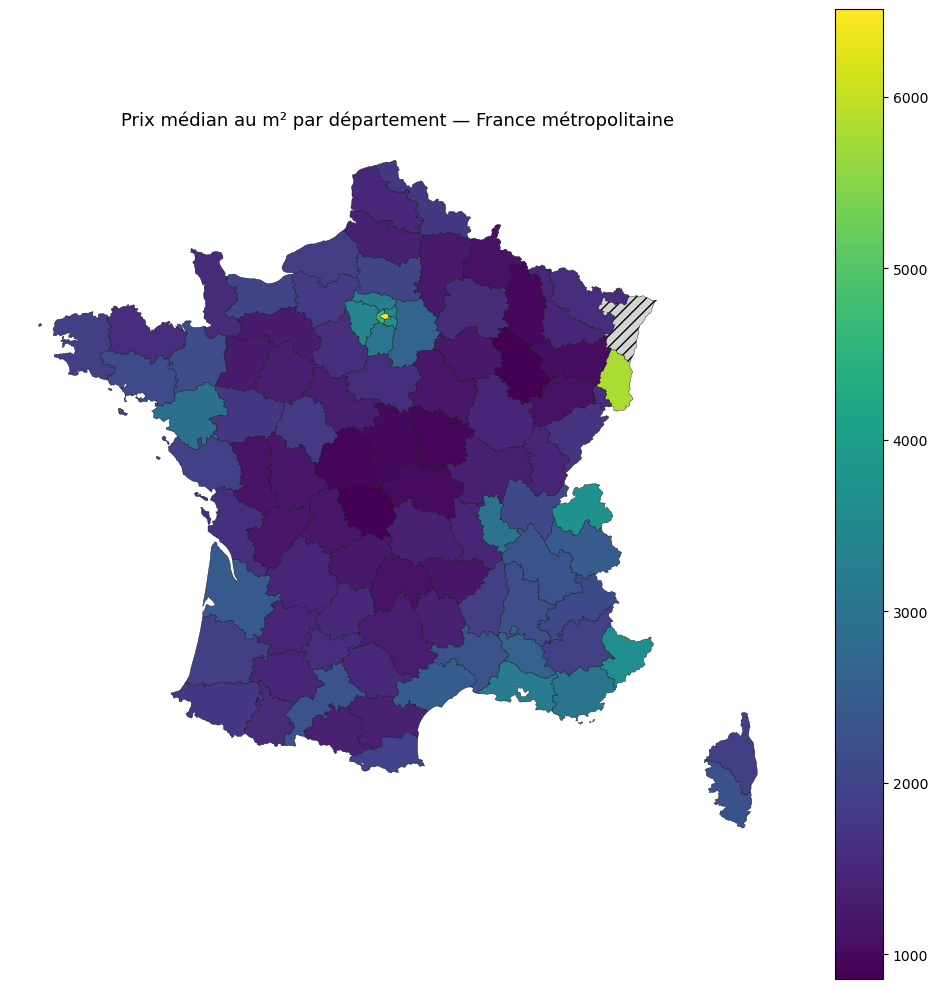

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_prix_m2_median_france_metropolitaine.png


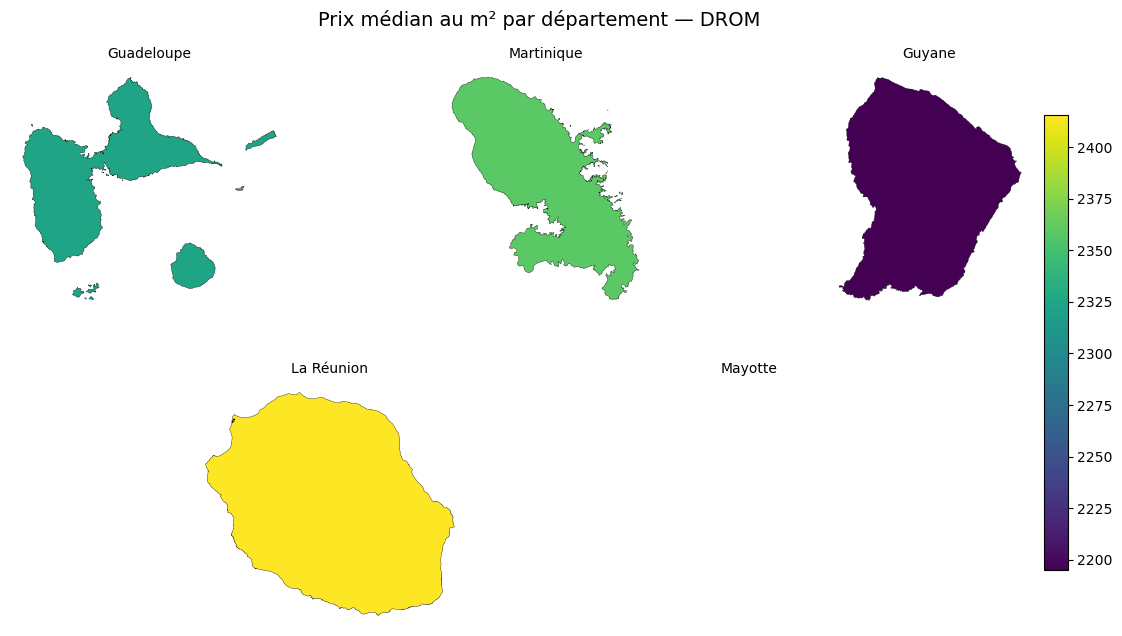

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_prix_m2_median_drom.png


[WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_prix_m2_median_france_metropolitaine.png'),
 WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_prix_m2_median_drom.png')]

In [ ]:
# Carte prix médian
# Bloc de traitement du pipeline DVF.

plot_department_map(
    dep_map,
    column="dep_prix_m2_median",
    title="Prix médian au m² par département",
    filename="carte_dep_prix_m2_median.png",
    categorical=False,
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — prix médians au m² par département</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes présentent les prix médians au m² agrégés à l’échelle départementale en métropole et dans les DROM. L’utilisation de la médiane permet de limiter l’influence des transactions atypiques. La structure spatiale du marché immobilier français apparaît nettement. Les niveaux de prix les plus élevés se concentrent principalement en Île-de-France, sur le littoral méditerranéen, dans certains territoires frontaliers et autour des grandes métropoles régionales. À l’inverse, plusieurs départements du centre de la France présentent des niveaux de prix plus accessibles, cohérents avec une pression foncière et démographique plus modérée. Les territoires littoraux et touristiques affichent également des niveaux de valorisation élevés, en lien avec leur attractivité résidentielle et la présence de résidences secondaires. Les DROM présentent des profils plus différenciés. La Réunion apparaît comme le marché ultramarin le plus valorisé, tandis que la Guyane présente des niveaux de prix plus faibles et une structure territoriale distincte. Ces cartes offrent une lecture macroterritoriale cohérente des dynamiques immobilières françaises. Elles confirment la qualité des agrégations DVF et la robustesse des enrichissements géographiques intégrés au pipeline territorial.</div>
</div>

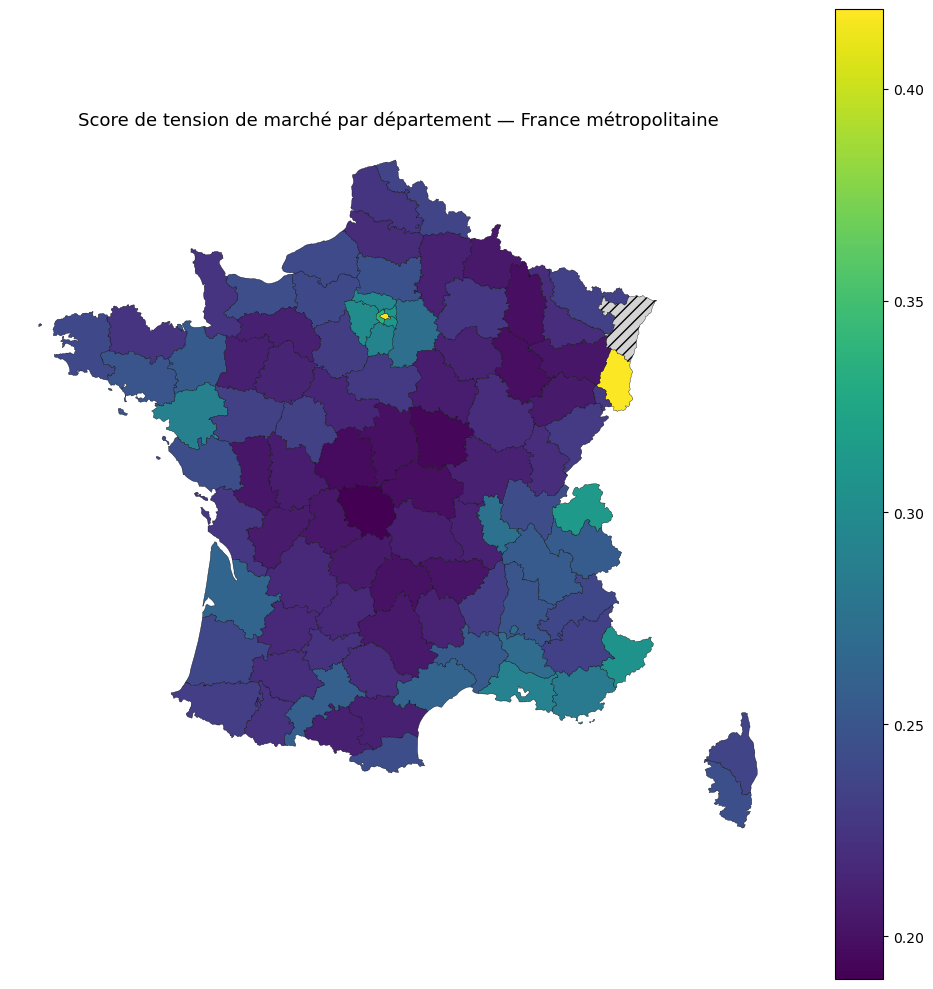

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_score_tension_marche_france_metropolitaine.png


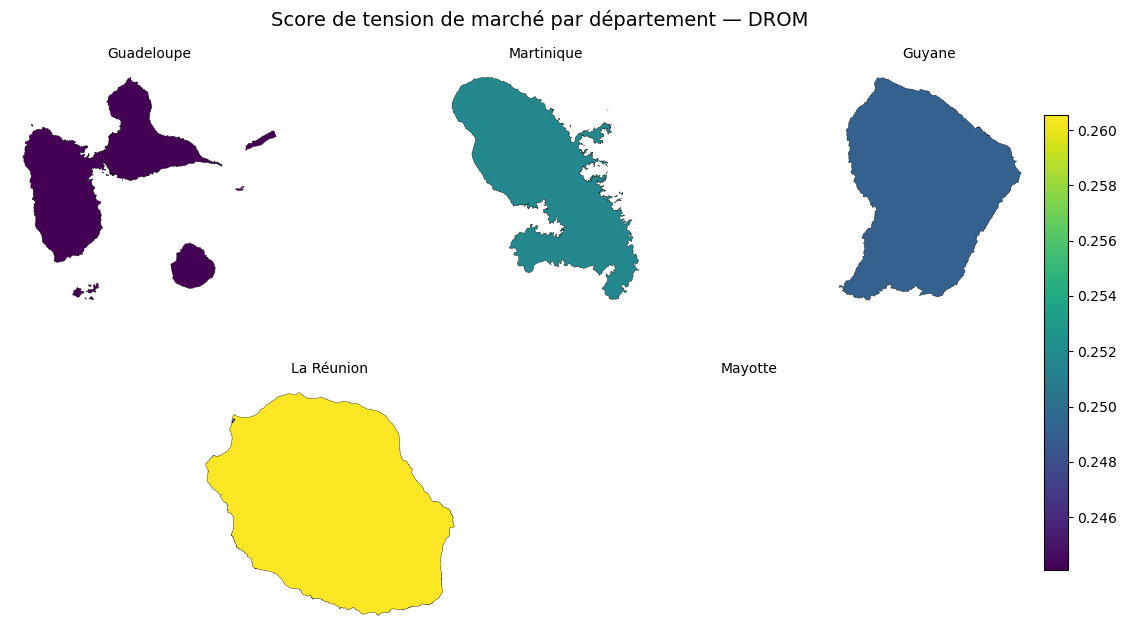

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_score_tension_marche_drom.png


[WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_score_tension_marche_france_metropolitaine.png'),
 WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_score_tension_marche_drom.png')]

In [29]:
# Bloc de traitement du pipeline DVF.

plot_department_map(
    dep_map,
    column="dep_score_tension_marche",
    title="Score de tension de marché par département",
    filename="carte_dep_score_tension_marche.png",
    categorical=False,
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — score de tension de marché</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes représentent un score composite de tension immobilière construit à partir du niveau de prix, du volume de transactions et de la dispersion des prix. Les niveaux de tension les plus élevés se concentrent principalement en Île-de-France, sur l’arc méditerranéen et autour des principales métropoles régionales. Ces territoires combinent généralement forte attractivité, pression foncière et activité transactionnelle soutenue. Le score ne reflète pas uniquement le niveau de prix : il intègre également la liquidité et la cohérence du marché. Deux territoires présentant des prix similaires peuvent ainsi afficher des niveaux de tension différents selon leur activité ou leur dispersion de prix. Les DROM présentent des profils plus contrastés. La Réunion apparaît comme le territoire ultramarin le plus tendu, tandis que la Guadeloupe, la Martinique et la Guyane affichent des niveaux plus modérés. Cet indicateur apporte une lecture plus structurelle des marchés immobiliers et constitue un enrichissement pertinent pour les futures analyses territoriales et modèles prédictifs. Le score reste toutefois un indicateur construit à partir de pondérations définies dans le pipeline. Il doit donc être interprété comme une mesure analytique synthétique et non comme un indicateur officiel.</div>
</div>

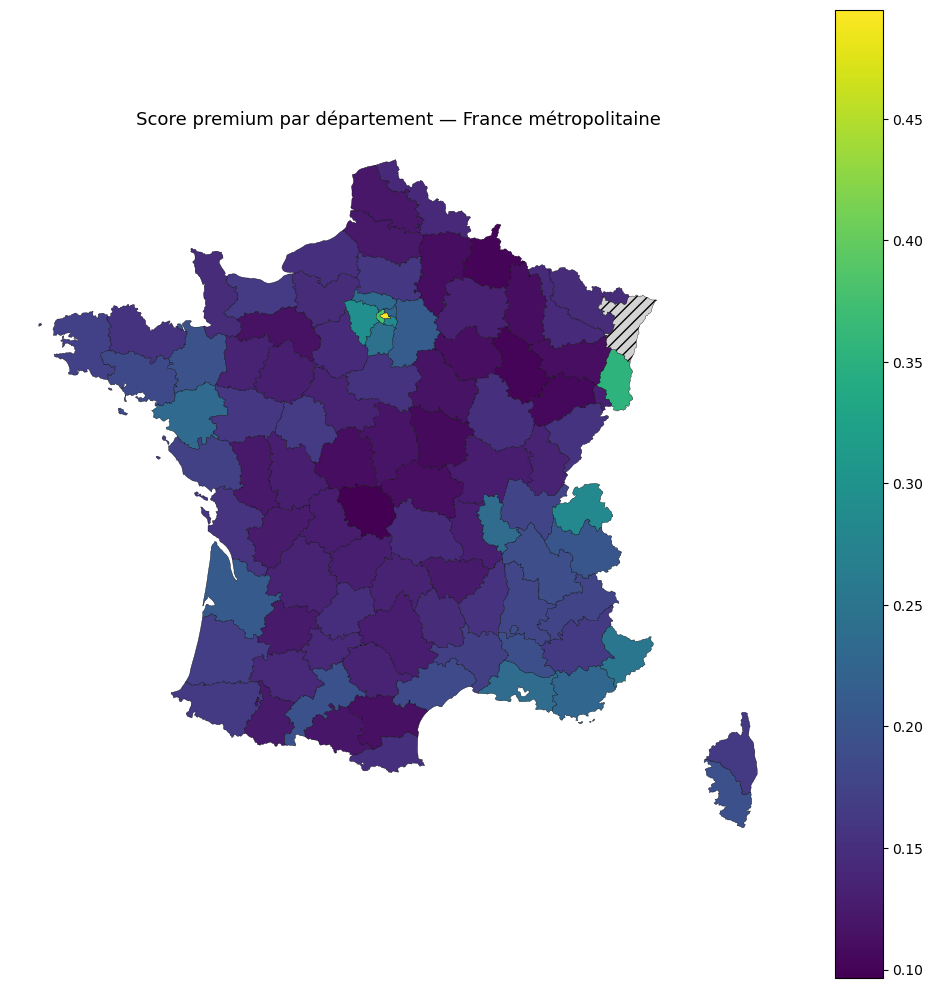

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_score_premium_marche_france_metropolitaine.png


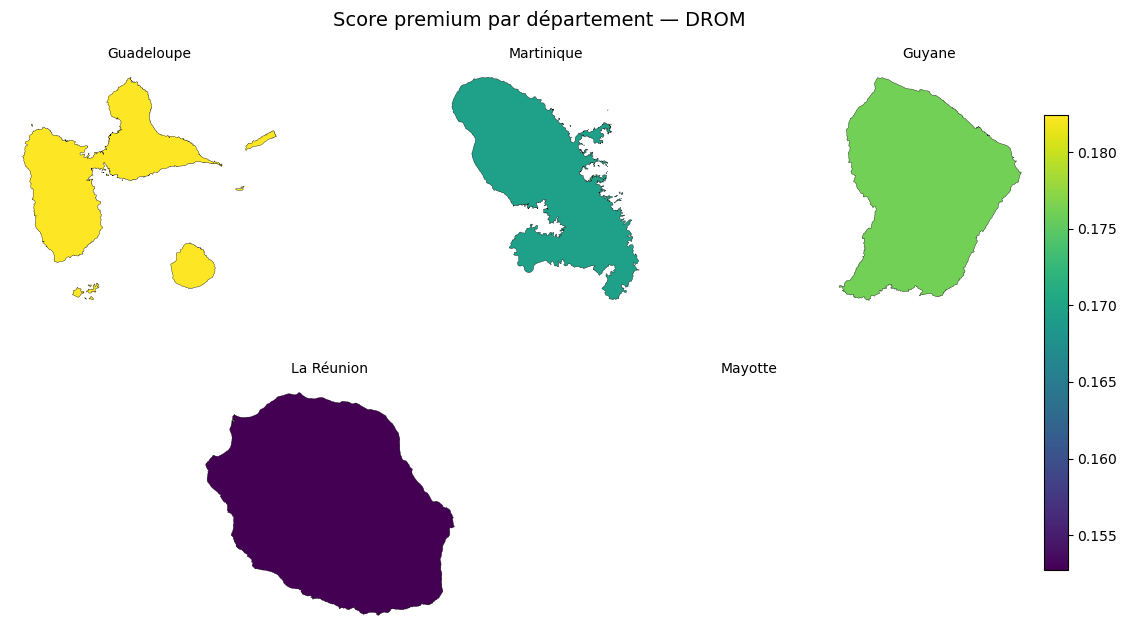

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_score_premium_marche_drom.png


[WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_score_premium_marche_france_metropolitaine.png'),
 WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_score_premium_marche_drom.png')]

In [ ]:
# Carte de score premium
# Bloc de traitement du pipeline DVF.

plot_department_map(
    dep_map,
    column="dep_score_premium_marche",
    title="Score premium par département",
    filename="carte_dep_score_premium_marche.png",
    categorical=False,
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — score premium de marché</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes représentent un score composite de premiumisation des marchés immobiliers construit principalement à partir du niveau de prix et des revenus médians. Les scores les plus élevés se concentrent en Île-de-France, sur certains littoraux attractifs et autour des principales métropoles régionales. Ces territoires combinent généralement forte valorisation immobilière, attractivité résidentielle et revenus plus élevés. Le score premium se distingue du score de tension : il mesure davantage le niveau de valorisation patrimoniale et le standing économique des territoires que l’intensité transactionnelle du marché. Les DROM présentent des profils différenciés. La Guadeloupe et la Martinique affichent des niveaux relativement élevés, tandis que la Guyane apparaît plus modérée. La Réunion présente un marché dynamique mais moins premium au regard des revenus intégrés dans le score. Cet indicateur apporte une lecture socio-économique complémentaire des marchés résidentiels et constitue un enrichissement pertinent pour les futures segmentations territoriales et analyses de valorisation immobilière. Le score reste toutefois un indicateur construit à partir de pondérations définies dans le pipeline. Il doit être interprété comme une synthèse analytique et non comme une mesure officielle du niveau de gamme des marchés immobiliers.</div>
</div>

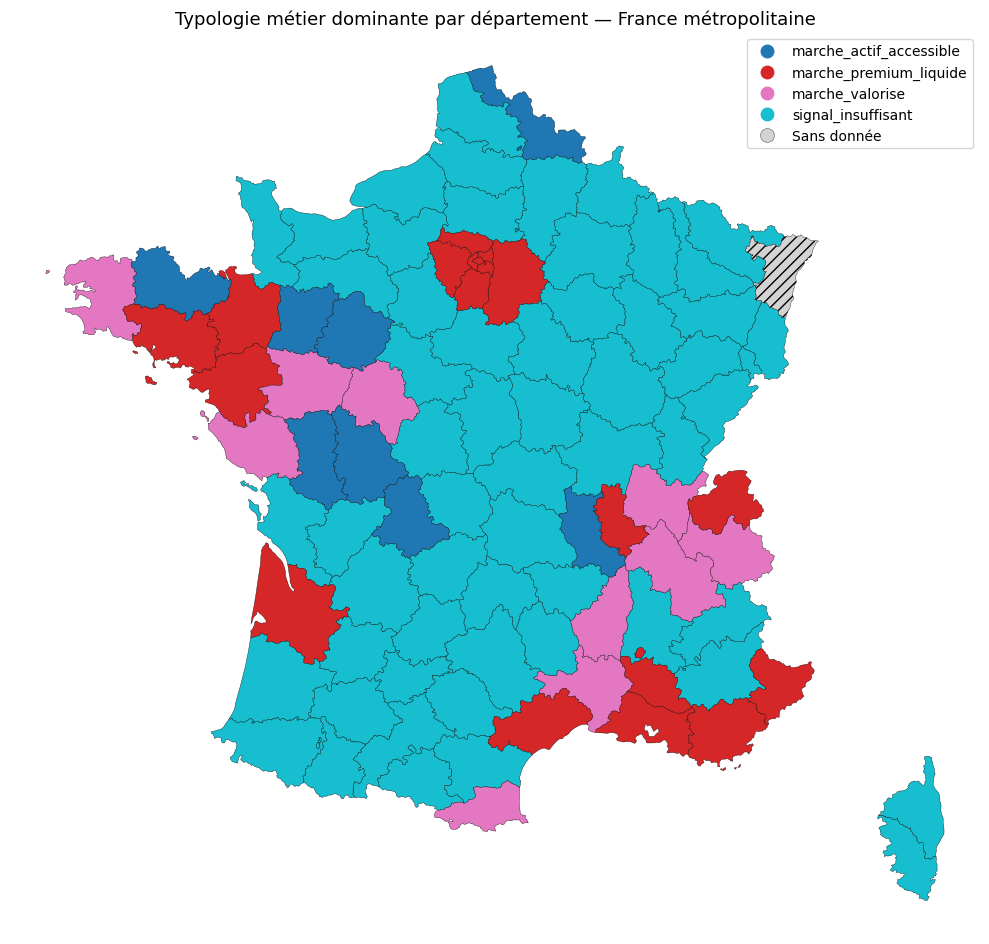

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_typologie_metier_dominante_france_metropolitaine.png


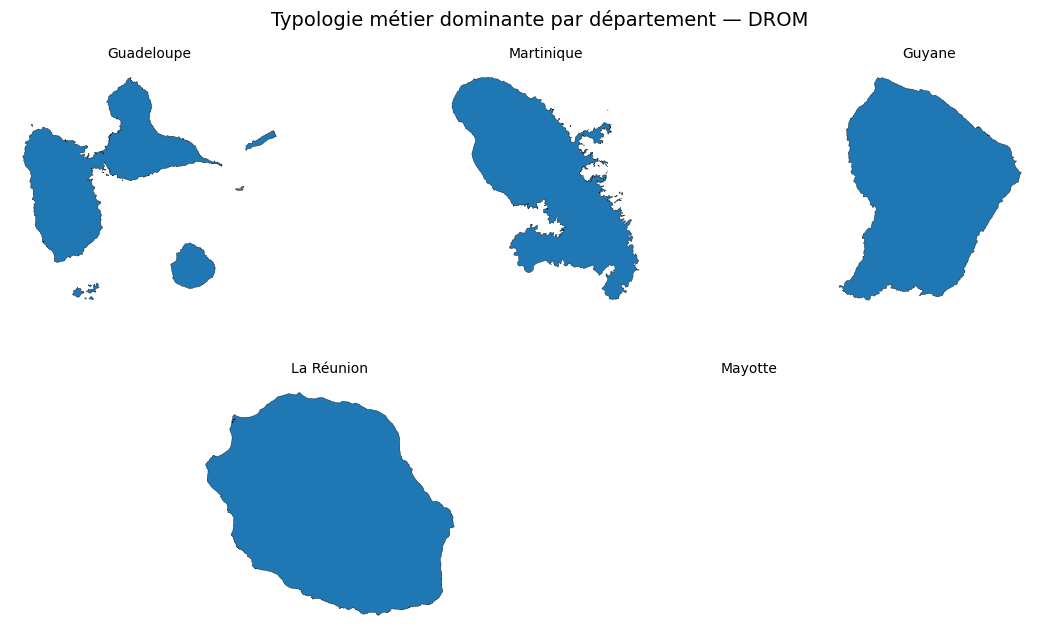

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_typologie_metier_dominante_drom.png


[WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_typologie_metier_dominante_france_metropolitaine.png'),
 WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_typologie_metier_dominante_drom.png')]

In [ ]:
# Carte typologie métier dominante
# Bloc de traitement du pipeline DVF.

plot_department_map(
    dep_map,
    column="dep_typologie_metier_dominante",
    title="Typologie métier dominante par département",
    filename="carte_dep_typologie_metier_dominante.png",
    categorical=True,
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — typologie métier dominante par département</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes représentent la typologie métier dominante au sein de chaque département à partir des segments construits au niveau IRIS. La catégorie `signal_insuffisant` reste majoritaire sur une grande partie du territoire. Ce résultat reflète la granularité fine du maillage IRIS et la faible liquidité observée dans de nombreux espaces ruraux ou résidentiels peu actifs. Les typologies `marche_premium_liquide` se concentrent principalement en Île-de-France, sur certains littoraux attractifs et autour des principales métropoles. Ces territoires combinent généralement niveaux de prix élevés et forte activité transactionnelle. Les catégories `marche_valorise` et `marche_actif_accessible` apparaissent davantage dans les espaces périurbains et plusieurs bassins régionaux dynamiques, traduisant des marchés plus accessibles mais relativement actifs. Les DROM présentent des profils plus homogènes, dominés par des marchés actifs mais moins premium au regard des niveaux de valorisation observés en métropole. Cette typologie fournit une lecture métier synthétique et directement interprétable des dynamiques immobilières territoriales. Elle complète l’approche statistique du clustering en proposant une segmentation fondée sur des règles économiques explicites et lisibles.</div>
</div>

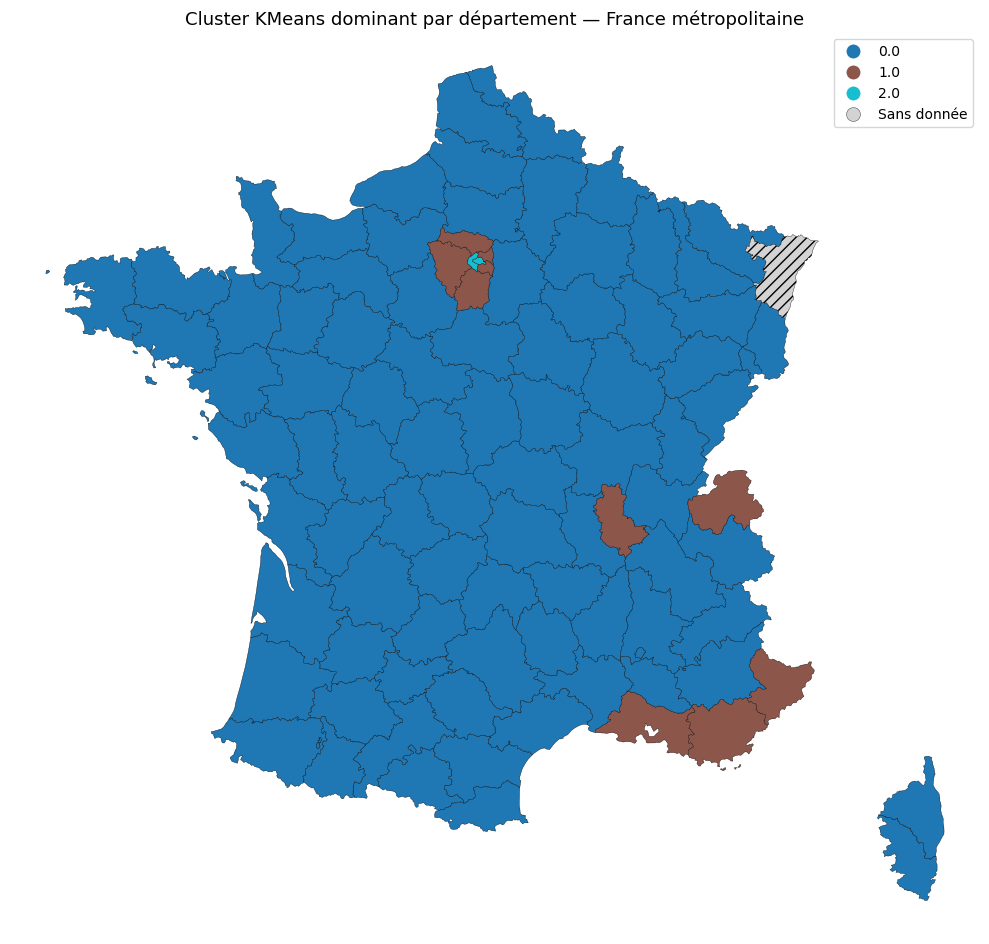

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_cluster_kmeans_dominant_france_metropolitaine.png


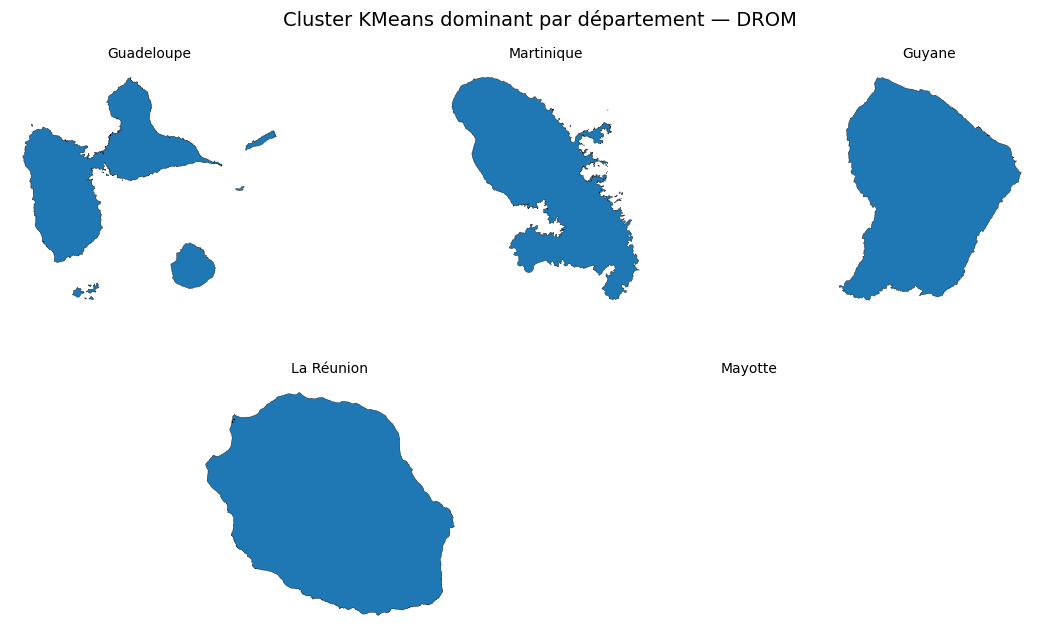

Carte exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\maps\carte_dep_cluster_kmeans_dominant_drom.png


[WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_cluster_kmeans_dominant_france_metropolitaine.png'),
 WindowsPath('C:/Users/club_/OneDrive/13_DOCUMENT/SYSTEME_AIDE_DECISION_IMMOBILIERE/reports/06_typologies_marche_immobilier/maps/carte_dep_cluster_kmeans_dominant_drom.png')]

In [ ]:
# Carte du cluster Kmeans dominant
# Bloc de traitement du pipeline DVF.

plot_department_map(
    dep_map,
    column="dep_cluster_kmeans_dominant",
    title="Cluster KMeans dominant par département",
    filename="carte_dep_cluster_kmeans_dominant.png",
    categorical=True,
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — cluster KMeans dominant par département</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces cartes représentent le cluster KMeans majoritaire au sein de chaque département. Contrairement aux typologies métier, les clusters sont construits automatiquement à partir des similarités statistiques observées entre IRIS. Le cluster dominant couvre une large partie du territoire, traduisant la présence majoritaire de marchés résidentiels relativement homogènes ou intermédiaires à l’échelle nationale. Les clusters minoritaires apparaissent principalement en Île-de-France, sur le littoral méditerranéen et autour de certains pôles métropolitains. Ils correspondent vraisemblablement à des marchés plus spécifiques, plus valorisés ou présentant des dynamiques territoriales distinctes. Le clustering permet ainsi de détecter des structures de marché moins visibles dans une lecture départementale classique ou dans une segmentation fondée uniquement sur des règles métier. Les DROM restent majoritairement rattachés au cluster principal. Ce résultat peut s’expliquer par leur faible poids statistique dans l’échantillon national et par la standardisation des variables utilisées dans le modèle. Les numéros de clusters ne portent pas de signification intrinsèque : ils représentent uniquement des groupes statistiques identifiés par l’algorithme. Leur interprétation doit donc s’appuyer sur les profils territoriaux, les variables dominantes et les analyses comparatives. Globalement, le clustering met en évidence une structure territoriale cohérente du marché immobilier français, tout en confirmant que les marchés atypiques restent relativement concentrés géographiquement.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Commentaires — cohérence globale des cartes de marché immobilier</h3>
  <div style="color: #4b5563; font-size: 14px;">L’ensemble des cartes produites présente une forte cohérence économique, géographique et statistique. Les différentes représentations décrivent des dynamiques territoriales convergentes à travers des approches complémentaires. Les territoires les plus valorisés ressortent de manière récurrente : Île-de-France ; littoral méditerranéen ; grandes métropoles ; zones touristiques et littorales attractives. Ces espaces cumulent généralement niveaux de prix élevés, forte liquidité, revenus plus importants, densité élevée et tension immobilière soutenue. À l’inverse, les territoires plus ruraux ou moins denses présentent des marchés plus accessibles, moins liquides et globalement moins tendus. Les variables territoriales — revenus, densité, vacance ou équipements — apparaissent globalement cohérentes avec cette structure immobilière. Les scores composites, les typologies métier et le clustering KMeans convergent également vers des structures territoriales proches. Cette cohérence renforce la crédibilité des segmentations produites et confirme que les catégories métier reposent sur des signaux statistiques réels. Les DROM présentent des profils plus spécifiques et parfois plus sensibles aux effets de volume, mais les dynamiques observées restent globalement cohérentes avec les indicateurs socio-économiques et immobiliers construits dans le pipeline. Certaines limites restent visibles, notamment l’effet de l’agrégation départementale, qui masque une partie importante des disparités locales, ainsi qu’une séparation parfois modérée entre clusters à l’échelle nationale. Globalement, le pipeline produit une lecture territoriale robuste et économiquement crédible du marché immobilier français. Les différentes cartes se complètent et renforcent la cohérence du feature store territorial construit dans le projet.</div>
</div>

In [ ]:
# Export données géographiques
# Bloc de traitement du pipeline DVF.

if GEOPANDAS_AVAILABLE and dep_map is not None:
    # Export CSV sans géométrie.
    dep_map.drop(columns="geometry").to_csv(
        TABLE_DIR / "24_features_departementales_cartographie.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # Export SIG optionnel.
    try:
        dep_map.to_file(MAP_DIR / "departements_features_marche_v6_1.gpkg", driver="GPKG")
        print("GeoPackage exporté.")
    except Exception as e:
        print(f"GeoPackage non exporté : {e}")

    display(dep_map.drop(columns="geometry").head())


GeoPackage exporté.


,code_departement,nom_departement,dep_prix_m2_median,dep_transactions_count,dep_score_tension_marche,dep_score_premium_marche,dep_score_liquidite_marche,dep_score_atypicite_marche,dep_typologie_metier_dominante,dep_cluster_kmeans_dominant
0,01,Ain,"2,070.800","36,857.000",0.242,0.177,0.005,0.014,marche_valorise,0.000
1,02,Aisne,"1,245.977","25,305.000",0.211,0.110,0.002,0.012,signal_insuffisant,0.000
2,03,Allier,"1,019.434","18,042.000",0.198,0.111,0.002,0.016,signal_insuffisant,0.000
3,04,Alpes-de-Haute-Provence,"1,957.528","14,343.000",0.233,0.164,0.002,0.018,signal_insuffisant,0.000
4,05,Hautes-Alpes,"2,105.699","15,658.000",0.238,0.176,0.002,0.019,signal_insuffisant,0.000


In [ ]:
# SEPARATION DES COLONNES PAR USAGE
#
# Cette section construit un dictionnaire fonctionnel des variables du feature store.
# L’objectif est de documenter :
#   - le rôle métier de chaque colonne ;
#   - son usage analytique ;
#   - son type technique.
#
# Cette étape est importante pour :
#   - la lisibilité du projet ;
#   - la gouvernance des données ;
#   - la préparation des modèles ;
#   - la maintenance future du pipeline.
#
# On distingue ici plusieurs familles :
#   - clés territoriales ;
#   - variables métier immobilières ;
#   - variables de clustering ;
#   - variables territoriales ;
#   - variables techniques ou secondaires.


# 1. Colonnes identifiantes (clés territoriales)
# Ces variables servent à identifier les territoires.
# Elles ne sont généralement pas utilisées directement comme features
# dans les modèles mais permettent :
#   - les jointures ;
#   - les agrégations ;
#   - les cartes ;
#   - les exports analytiques.

KEY_COLUMNS = [
    c for c in [
        "code_iris",
        "code_commune",
        "code_departement",
        "nom_iris",
        "nom_commune",
    ]
    if c in market_iris.columns
]

# 2. Variables métier immobilières
#
# Ces variables décrivent directement le fonctionnement du marché :
#   - niveaux de prix ;
#   - dispersion ;
#   - activité transactionnelle ;
#   - typologie métier.
#
# Elles sont fortement interprétables économiquement.

BUSINESS_COLUMNS = [
    "prix_m2_median",
    "prix_m2_mean",
    "prix_m2_q25",
    "prix_m2_q75",
    "dispersion_prix_iqr",
    "dispersion_prix_relative",
    "transactions_count",
    "transactions_par_mois",
    "signal_marche_fiable",
    "bucket_prix",
    "bucket_volume",
    "bucket_dispersion",
    "typologie_metier",
]

# On conserve uniquement les colonnes réellement présentes
# dans le DataFrame final.
BUSINESS_COLUMNS = [
    c for c in BUSINESS_COLUMNS
    if c in market_iris.columns
]


# 3. Variables issues du clustering
#
# Ces variables proviennent :
#   - du modèle KMeans ;
#   - de la PCA ;
#   - des variables utilisées pour segmenter les IRIS.
#
# Elles décrivent des proximités statistiques
# entre territoires similaires.

CLUSTER_COLUMNS = [
    "cluster_kmeans",
    "distance_centroid_cluster",
    "pca_1",
    "pca_2",
] + cluster_features

CLUSTER_COLUMNS = [
    c for c in CLUSTER_COLUMNS
    if c in market_iris.columns
]
# 4. Variables territoriales externes

# Ces variables proviennent :
#   - des enrichissements INSEE ;
#   - des densités calculées ;
#   - des équipements ;
#   - du contexte socio-économique.
#
# Elles permettent de contextualiser
# le fonctionnement immobilier local.

TERRITORIAL_COLUMNS = [
    c for c in territorial_cols + [
        "densite_population_calculee",
        "densite_logements_calculee",
    ]
    if c in market_iris.columns
]

# 5. Construction du dictionnaire d’usage
# On parcourt toutes les colonnes du DataFrame final.
#
# Chaque variable reçoit :
#   - une catégorie fonctionnelle ;
#   - un type technique pandas.
#
# Cela permet de construire un véritable data dictionary exploitable.

COLUMN_USAGE = []

for col in market_iris.columns:

    # Variables identifiantes.
    if col in KEY_COLUMNS:
        usage = "key"

    # Variables métier immobilières.
    elif col in BUSINESS_COLUMNS:
        usage = "business_typology"

    # Variables issues du clustering.
    elif col in CLUSTER_COLUMNS:
        usage = "clustering"

    # Variables territoriales externes.
    elif col in TERRITORIAL_COLUMNS:
        usage = "territorial_context"

    # Toutes les autres variables sont considérées :
    #   - techniques ;
    #   - intermédiaires ;
    #   - secondaires ;
    #   - ou peu utilisées directement.
    else:
        usage = "technical_or_secondary"

    COLUMN_USAGE.append({
        "colonne": col,
        "usage": usage,
        "type": str(market_iris[col].dtype),
    })

# Conversion finale en DataFrame documentaire.
column_usage = pd.DataFrame(COLUMN_USAGE)

# Export du dictionnaire d’usage.
export_table(column_usage, "16_column_usage_dictionary.csv")

# Affichage partiel pour contrôle visuel.
display(column_usage.head(80))


# 6. Ajout explicite des features 

# Certaines features du modèle final peuvent :
#   - ne pas être présentes dans le dictionnaire précédent ;
#   - avoir été générées plus tard dans le pipeline.
#
# On les ajoute explicitement afin de garantir :
#   - une documentation exhaustive ;
#   - une traçabilité complète des variables utilisées.

for feature_col in MODEL_FEATURES_ALL:

    # On ajoute uniquement les variables absentes.
    if feature_col not in column_usage["colonne"].values:

        column_usage = pd.concat([
            column_usage,

            pd.DataFrame([{
                "colonne": feature_col,
                "usage": "model_feature_v6",
                "type": str(market_iris[feature_col].dtype),
            }])

        ], ignore_index=True)

# Export final du dictionnaire enrichi.
export_table(column_usage, "22_column_usage_dictionary_v6.csv")

# Contrôle visuel.
display(column_usage.head(100))

,colonne,usage,type
0,code_iris,key,string
1,prix_m2_median,business_typology,float64
2,prix_m2_mean,business_typology,float64
3,prix_m2_q25,business_typology,float64
4,prix_m2_q75,business_typology,float64
5,prix_m2_std,technical_or_secondary,float64
6,transactions_count,business_typology,int64
7,valeur_fonciere_median,technical_or_secondary,float64
8,date_min,technical_or_secondary,datetime64[ns]
9,date_max,technical_or_secondary,datetime64[ns]


,colonne,usage,type
0,code_iris,key,string
1,prix_m2_median,business_typology,float64
2,prix_m2_mean,business_typology,float64
3,prix_m2_q25,business_typology,float64
4,prix_m2_q75,business_typology,float64
5,prix_m2_std,technical_or_secondary,float64
6,transactions_count,business_typology,int64
7,valeur_fonciere_median,technical_or_secondary,float64
8,date_min,technical_or_secondary,datetime64[ns]
9,date_max,technical_or_secondary,datetime64[ns]


In [ ]:
 
# EXPORTS FINAUX - NOMENCLATURE CANONIQUE
 

# Base IRIS complète avec analyses, typologies, clusters et scores.
market_iris.to_parquet(TYPOLOGIES_IRIS_OUTPUT_PATH, index=False)

# Feature store IRIS complet.
iris_feature_store.to_parquet(IRIS_FEATURE_STORE_OUTPUT_PATH, index=False)
iris_feature_store.to_csv(TABLE_DIR / "df_iris_feature_store_marche.csv", index=False, encoding="utf-8-sig")

# Feature store prudent anti-leakage strict.
iris_feature_store_strict_safe.to_parquet(IRIS_FEATURE_STORE_STRICT_OUTPUT_PATH, index=False)

# Bases transactionnelles enrichies pour la modélisation.
df_model_features_full.to_parquet(MODEL_FULL_OUTPUT_PATH, index=False)
df_model_features_strict_safe.to_parquet(MODEL_STRICT_SAFE_OUTPUT_PATH, index=False)

# Rapport QA final.
qa_final = pd.DataFrame([
    {"indicateur": "source_file", "valeur": source_file.name},
    {"indicateur": "input_path", "valeur": str(INPUT_PATH)},
    {"indicateur": "nb_lignes_source", "valeur": len(df_raw)},
    {"indicateur": "nb_lignes_base_market", "valeur": len(base_market)},
    {"indicateur": "nb_iris_typologies", "valeur": len(market_iris)},
    {"indicateur": "nb_features_model_all", "valeur": len(MODEL_FEATURES_ALL)},
    {"indicateur": "nb_features_model_strict_safe", "valeur": len(MODEL_FEATURES_STRICT_SAFE)},
    {"indicateur": "nb_cluster_features", "valeur": len(cluster_features)},
    {"indicateur": "best_k", "valeur": best_k},
    {"indicateur": "min_transactions_marche_fiable", "valeur": CONFIG["min_transactions_marche_fiable"]},
    {"indicateur": "date_execution", "valeur": RUN_DATE},
])
export_table(qa_final, "23_qa_final_typologies_marche.csv")

# Manifest pour traçabilité.
manifest = {
    "notebook": "06_typologies_marche_immobilier",
    "run_date": RUN_DATE,
    "input_path": str(INPUT_PATH),
    "source_file": str(source_file),
    "outputs": {
        "typologies_iris": str(TYPOLOGIES_IRIS_OUTPUT_PATH),
        "iris_feature_store_full": str(IRIS_FEATURE_STORE_OUTPUT_PATH),
        "iris_feature_store_strict_safe": str(IRIS_FEATURE_STORE_STRICT_OUTPUT_PATH),
        "model_dataframe_full": str(MODEL_FULL_OUTPUT_PATH),
        "model_dataframe_strict_safe": str(MODEL_STRICT_SAFE_OUTPUT_PATH),
        "tables_dir": str(TABLE_DIR),
        "figures_dir": str(FIG_DIR),
        "maps_dir": str(MAP_DIR),
    },
    "config": CONFIG,
    "cluster_features": cluster_features,
    "model_features_all": MODEL_FEATURES_ALL,
    "model_features_strict_safe": MODEL_FEATURES_STRICT_SAFE,
    "required_columns": REQUIRED_COLUMNS,
    "methodological_warning": (
        "Les features directement dérivées des prix DVF agrégés doivent être recalculées en train-only, "
        "out-of-fold ou sur fenêtre temporelle antérieure avant un modèle supervisé de prix."
    ),
}

manifest_path = REPORTS_DIR / "manifest_typologies_marche.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("Exports produits :")
for p in [
    TYPOLOGIES_IRIS_OUTPUT_PATH,
    IRIS_FEATURE_STORE_OUTPUT_PATH,
    IRIS_FEATURE_STORE_STRICT_OUTPUT_PATH,
    MODEL_FULL_OUTPUT_PATH,
    MODEL_STRICT_SAFE_OUTPUT_PATH,
    TABLE_DIR,
    FIG_DIR,
    MAP_DIR,
    manifest_path,
]:
    print("-", p)

display(qa_final)


Exports produits :
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_typologies_marche.parquet
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_feature_store_marche.parquet
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_iris_feature_store_marche_strict_safe.parquet
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_typologie_marche.parquet
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_typologie_marche_strict_safe.parquet
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\tables
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\06_typologies_marche_immobilier\figures
- C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\reports\0

,indicateur,valeur
0,source_file,df_biens_residentiels_territoire.parquet
1,input_path,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
2,nb_lignes_source,3885803
3,nb_lignes_base_market,3804204
4,nb_iris_typologies,47734
5,nb_features_model_all,25
6,nb_features_model_strict_safe,12
7,nb_cluster_features,10
8,best_k,3
9,min_transactions_marche_fiable,20


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce notebook construit un référentiel territorial de marchés immobiliers à l’échelle IRIS en combinant typologies métier, segmentation KMeans, scores composites et enrichissements territoriaux. Les principaux artefacts produits sont le feature store territorial, les typologies de marché, les scores de segmentation et la base transactionnelle enrichie destinée aux futures phases d’analyse et de modélisation. Les résultats obtenus restent dépendants de la qualité et du volume du signal transactionnel disponible à l’échelle IRIS. Les territoires faiblement liquides ou peu transactionnels doivent donc être interprétés avec prudence.</div>
</div>